In [1]:
# Dataset Creation Imports
import glob
import pandas as pd
import yaml
import itertools
from pymatgen.core import Structure, Element
import torch
import torch.nn as nn
from torch.optim import Adam
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn.conv import TransformerConv
from torch_geometric.nn.glob import global_mean_pool
import numpy as np
from torch_geometric.nn import GCNConv
from torch_geometric.nn import GATConv
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.nn import DimeNet
import math
np.math = math
import torch_sparse
from torch_sparse import SparseTensor
import torch_scatter
import torch_cluster
import torch_spline_conv
from torch_geometric.nn import GlobalAttention
from torch_geometric.nn import MessagePassing

In [ ]:
class GNNModel(nn.Module):
    def __init__(self, n_atom_features, n_output_freqs, edge_dim=1):
        super().__init__()
        hidden_channels = 16
        dimnet_hidden_channels = 64
        self.n_atom_features = n_atom_features
        self.dimenet = DimeNet(
            hidden_channels=dimnet_hidden_channels,
            out_channels=dimnet_hidden_channels,
            num_blocks=1,
            num_bilinear=4,
            num_spherical=10,
            num_radial=4,
        )
        self.bn_dimnet = nn.LayerNorm(dimnet_hidden_channels)

        self.initial_mlp = nn.Sequential(
            nn.Linear(n_atom_features, hidden_channels),
            nn.LayerNorm(hidden_channels),
            nn.ReLU()
        )

        self.embedding = TransformerConv(
            n_atom_features, hidden_channels, edge_dim=edge_dim
        )
        self.convs = nn.ModuleList(
            [
                TransformerConv(hidden_channels, hidden_channels, edge_dim=edge_dim)
                for _ in range(1)
            ]
        )

        self.bn_embedding = nn.LayerNorm(hidden_channels)
        self.bns = nn.ModuleList(
            [nn.LayerNorm(hidden_channels) for _ in range(len(self.convs))]
        )

        self.global_mlp = nn.Sequential(nn.Linear(1, 1), nn.ReLU(), nn.LayerNorm(1))
        self.u_scale_factor = nn.Parameter(torch.ones(1))

        temp = 2048
        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels + dimnet_hidden_channels + 1, temp // 4),
            nn.LayerNorm(temp // 4),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(temp // 4, temp // 2),
            nn.LayerNorm(temp // 2),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(temp // 2, temp // 1),
            nn.LayerNorm(temp // 1),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(temp // 1, 20*1071),
        )
        self.scale_factor = nn.Parameter(torch.ones(1))
        gate_nn = nn.Sequential(nn.Linear(hidden_channels, 1), nn.Sigmoid())
        self.pool = GlobalAttention(gate_nn=gate_nn)

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
        )

        geom_embedding = self.dimenet(data.z, data.pos, data.batch)
        geom_embedding = self.bn_dimnet(geom_embedding)
        geom_embedding = geom_embedding.tanh()

        x = self.initial_mlp(x)

        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index, edge_attr)
            x = bn(x)
            x = x.tanh()

        pooled_x = self.pool(x, batch)

        combined_vector = torch.cat(
            [geom_embedding, self.scale_factor * pooled_x, self.u_scale_factor * u],
            dim=1,
        )
        output = self.mlp(combined_vector)
        
        # Calculate the number of atoms per structure in the batch
        # batch tensor contains the graph index for each node
        # Count nodes per graph to get n_atoms for each structure
        batch_size = int(batch.max().item()) + 1
        n_atoms_per_structure = torch.bincount(batch)
        
        # Calculate expected output size: 3 * n_atoms * 357 q-points for each structure
        # phonon bands = 3 * n_atoms (3 acoustic/optical modes per atom)
        n_qpoints = 357
        expected_outputs = n_atoms_per_structure * 3 * n_qpoints
        
        # Slice output for each structure based on its number of atoms
        result = []
        for i in range(batch_size):
            end_idx = expected_outputs[i].item()
            result.append(output[i, :end_idx])
        
        # Find maximum size and pad all outputs to match
        max_size = max(expected_outputs).item()
        padded_results = []
        for i in range(batch_size):
            curr_size = expected_outputs[i].item()
            if curr_size < max_size:
                # Pad with zeros to match max_size
                padding = torch.zeros(max_size - curr_size, device=output.device, dtype=output.dtype)
                padded_results.append(torch.cat([result[i], padding]))
            else:
                padded_results.append(result[i])
        
        # Stack the padded results
        return torch.stack(padded_results)

In [ ]:
LEARNING_RATE = 1e-3
BATCH_SIZE = 128  # Back to batch_size=32 for faster training
EPOCHS = 1000
RANDOM_SEED = 555

dataset_path = 'Bigdataset.pt'
try:
    dataset = torch.load(dataset_path, weights_only=False)
    print(f"Successfully loaded dataset with {len(dataset)} graphs from {dataset_path}")
except FileNotFoundError:
    print(f"Error: Dataset file not found at '{dataset_path}'.")
    exit()

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

np.random.shuffle(dataset) 
train_size = int(len(dataset) * 0.8)
val_dataset = dataset[train_size:]
train_dataset = dataset[:train_size]

# Custom collate function - exclude 'y' from batching, handle it separately
def custom_collate(data_list):
    """
    Custom collate: Let PyG batch everything except 'y', then pad 'y' manually.
    """
    from torch_geometric.data import Batch
    
    # Extract y tensors and their sizes (flatten if needed)
    y_list = [data.y.flatten() for data in data_list]  # Flatten to 1D
    y_sizes = torch.tensor([y.shape[0] for y in y_list], dtype=torch.long)
    max_y_size = y_sizes.max().item()
    
    # Pad y tensors to max size
    y_padded = []
    for y in y_list:
        if y.shape[0] < max_y_size:
            padding = torch.zeros(max_y_size - y.shape[0], dtype=y.dtype)
            y_padded.append(torch.cat([y, padding]))
        else:
            y_padded.append(y)
    
    # Stack padded y tensors [batch_size, max_y_size]
    y_batch = torch.stack(y_padded)
    
    # Use PyG's batching for everything EXCEPT y (exclude it)
    batch = Batch.from_data_list(data_list, exclude_keys=['y'])
    
    # Add our manually batched y
    batch.y = y_batch
    batch.y_sizes = y_sizes
    
    return batch

# Use standard PyTorch DataLoader
from torch.utils.data import DataLoader as TorchDataLoader
train_loader = TorchDataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=custom_collate)
val_loader = TorchDataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=custom_collate)

print(f"Training on {len(train_dataset)} samples, validating on {len(val_dataset)} samples.")
print(f"✅ Using batch_size={BATCH_SIZE} with custom collate function.")
print(f"✅ PyG batches all attributes except 'y', which is padded and batched manually.")

Successfully loaded dataset with 358 graphs from datasetWithAngles.pt
Training on 286 samples, validating on 72 samples.


c:\ProgramData\anaconda3\envs\cuda-pytorch\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [79]:
# 🎯 Custom Band-Averaged RMSE Loss Function
class BandAveragedRMSELoss(nn.Module):
    def __init__(self, n_qpoints=357, n_bands=24):
        super(BandAveragedRMSELoss, self).__init__()
        self.n_qpoints = n_qpoints
        self.n_bands = n_bands
        
    def forward(self, pred, target):
        """
        محاسبه Band-Averaged RMSE Loss
        pred: [batch_size, n_qpoints * n_bands] 
        target: [batch_size, n_qpoints * n_bands]
        """
        batch_size = pred.shape[0]
        
        # Reshape to [batch_size, n_qpoints, n_bands]
        pred_bands = pred.view(batch_size, self.n_qpoints, self.n_bands)
        target_bands = target.view(batch_size, self.n_qpoints, self.n_bands)
        
        # محاسبه MSE برای هر band بر روی همه samples و qpoints
        # [batch_size, n_bands]
        mse_per_band = torch.mean((pred_bands - target_bands) ** 2, dim=1)
        
        # محاسبه RMSE برای هر band
        # [batch_size, n_bands]  
        rmse_per_band = torch.sqrt(mse_per_band)
        
        # میانگین RMSE بر روی همه bands و samples
        band_averaged_rmse = torch.mean(rmse_per_band)
        
        return band_averaged_rmse

print("✅ Custom Band-Averaged RMSE Loss Function defined!")
print("📊 This loss function:")
print("   • Calculates RMSE for each of the 24 phonon bands separately")
print("   • Takes the average of all band RMSEs")  
print("   • Treats each band equally in the loss calculation")
print("   • Should improve band-wise prediction accuracy")

✅ Custom Band-Averaged RMSE Loss Function defined!
📊 This loss function:
   • Calculates RMSE for each of the 24 phonon bands separately
   • Takes the average of all band RMSEs
   • Treats each band equally in the loss calculation
   • Should improve band-wise prediction accuracy


In [80]:
# 🎯 Custom Power-4 Loss Function (More Sensitive to Large Errors)
class Power4Loss(nn.Module):
    def __init__(self):
        super(Power4Loss, self).__init__()
        
    def forward(self, pred, target):
        """
        محاسبه Power-4 Loss: Fourth root of mean fourth power
        Similar to RMSE but with power 4 instead of power 2
        More sensitive to large errors than RMSE
        """
        # محاسبه خطا
        errors = pred - target
        
        # توان 4 به جای توان 2
        fourth_power_errors = torch.pow(torch.abs(errors), 4)
        
        # میانگین
        mean_fourth_power = torch.mean(fourth_power_errors)
        
        # ریشه چهارم به جای جذر
        power4_loss = torch.pow(mean_fourth_power, 0.25)  # fourth root
        
        return power4_loss

# 🎯 Custom Power-3 Loss Function (Moderate Sensitivity to Large Errors)
class Power3Loss(nn.Module):
    def __init__(self):
        super(Power3Loss, self).__init__()
        
    def forward(self, pred, target):
        """
        محاسبه Power-3 Loss: Cube root of mean cubic power
        Moderate sensitivity between RMSE and Power-4
        Uses power 3 and cube root
        """
        # محاسبه خطا
        errors = pred - target
        
        # قدر مطلق و توان 3
        cubic_power_errors = torch.pow(torch.abs(errors), 3)
        
        # میانگین
        mean_cubic_power = torch.mean(cubic_power_errors)
        
        # ریشه سوم
        power3_loss = torch.pow(mean_cubic_power, 1.0/3.0)  # cube root
        
        return power3_loss

print("✅ Custom Power-4 Loss Function defined!")
print("📊 This loss function:")
print("   • Uses power 4 instead of power 2 (like RMSE)")
print("   • Takes fourth root instead of square root")  
print("   • MUCH more sensitive to large errors than RMSE")
print("   • Should penalize outliers more aggressively")
print("   • Formula: (mean(|pred - target|^4))^(1/4)")

print("\n✅ Custom Power-3 Loss Function defined!")
print("📊 This loss function:")
print("   • Uses power 3 instead of power 2 (like RMSE)")
print("   • Takes cube root instead of square root")  
print("   • MORE sensitive to large errors than RMSE")
print("   • Moderate sensitivity between RMSE and Power-4")
print("   • Formula: (mean(|pred - target|^3))^(1/3)")

✅ Custom Power-4 Loss Function defined!
📊 This loss function:
   • Uses power 4 instead of power 2 (like RMSE)
   • Takes fourth root instead of square root
   • MUCH more sensitive to large errors than RMSE
   • Should penalize outliers more aggressively
   • Formula: (mean(|pred - target|^4))^(1/4)

✅ Custom Power-3 Loss Function defined!
📊 This loss function:
   • Uses power 3 instead of power 2 (like RMSE)
   • Takes cube root instead of square root
   • MORE sensitive to large errors than RMSE
   • Moderate sensitivity between RMSE and Power-4
   • Formula: (mean(|pred - target|^3))^(1/3)


In [ ]:
import sys

# Custom loss function that handles padded values
class MaskedRMSELoss(nn.Module):
    def __init__(self):
        super(MaskedRMSELoss, self).__init__()
        
    def forward(self, pred, target, y_sizes=None):
        """
        Calculate RMSE loss while ignoring padded values.
        
        Args:
            pred: [batch_size, max_size] - predictions (padded)
            target: [batch_size, max_size] - targets (padded)
            y_sizes: [batch_size] - actual sizes before padding
        """
        if y_sizes is None:
            # If no sizes provided, compute normal RMSE
            return torch.sqrt(nn.MSELoss()(pred, target))
        
        # Calculate loss only on non-padded values
        total_loss = 0.0
        total_elements = 0
        
        for i in range(pred.shape[0]):
            actual_size = y_sizes[i].item()
            # Only compute loss on actual values, not padding
            pred_i = pred[i, :actual_size]
            target_i = target[i, :actual_size]
            
            total_loss += torch.sum((pred_i - target_i) ** 2)
            total_elements += actual_size
        
        # Return RMSE
        return torch.sqrt(total_loss / total_elements)



In [81]:
# 🔬 Physics-Informed Loss Functions for Phonon Predictions

class PhysicsInformedPhononLoss(nn.Module):
    """
    Physics-informed loss for phonon band structure prediction
    Incorporates fundamental physical constraints from lattice dynamics
    """
    def __init__(self, n_qpoints=357, n_bands=24, 
                 alpha=1.0,      # Base RMSE weight
                 beta=0.3,       # Acoustic sum rule weight
                 gamma=0.2,      # Smoothness weight
                 delta=0.15,     # Positive frequency weight
                 epsilon=0.1,    # Symmetry weight
                 zeta=0.05):     # Band ordering weight
        super().__init__()
        self.n_qpoints = n_qpoints
        self.n_bands = n_bands
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.delta = delta
        self.epsilon = epsilon
        self.zeta = zeta
        
    def forward(self, pred, target):
        """
        Calculate physics-informed loss with multiple constraints
        pred, target: [batch_size, n_qpoints * n_bands] or variable with padding
        """
        batch_size = pred.shape[0]
        
        # Handle variable size outputs - only use non-padded portion
        # Assume minimum is 8 atoms = 24 bands for now
        effective_length = self.n_qpoints * self.n_bands
        pred_active = pred[:, :effective_length]
        target_active = target[:, :effective_length]
        
        # Reshape to [batch_size, n_qpoints, n_bands]
        pred_bands = pred_active.view(batch_size, self.n_qpoints, self.n_bands)
        target_bands = target_active.view(batch_size, self.n_qpoints, self.n_bands)
        
        # 1️⃣ BASE LOSS: Standard RMSE
        base_loss = torch.sqrt(torch.mean((pred_bands - target_bands) ** 2))
        
        # 2️⃣ ACOUSTIC SUM RULE: First 3 acoustic bands should → 0 at Gamma point (q=0)
        # Physical constraint: ω(q→0) = 0 for acoustic modes (translational invariance)
        acoustic_modes = pred_bands[:, 0, :3]  # First 3 bands at first q-point (Gamma)
        acoustic_sum_rule_loss = torch.mean(acoustic_modes ** 2)
        
        # 3️⃣ SMOOTHNESS CONSTRAINT: Phonon bands should be smooth along q-path
        # Physical constraint: ∂ω/∂q should be continuous (no sudden jumps)
        q_gradients = torch.diff(pred_bands, dim=1)  # [batch, n_qpoints-1, n_bands]
        smoothness_loss = torch.mean(q_gradients ** 2)
        
        # 4️⃣ POSITIVE FREQUENCY CONSTRAINT: All frequencies must be ≥ 0
        # Physical constraint: ω² ≥ 0 (real frequencies only, no imaginary modes)
        negative_freqs = torch.clamp(-pred_bands, min=0)  # Penalize negative values
        positive_freq_loss = torch.mean(negative_freqs ** 2)
        
        # 5️⃣ SYMMETRY CONSTRAINT: Phonon dispersion should respect crystal symmetry
        # For hexagonal MAX phases, certain high-symmetry points should be related
        # Compare first and last q-points (often equivalent by symmetry)
        symmetry_loss = torch.mean((pred_bands[:, 0, :] - pred_bands[:, -1, :]) ** 2)
        
        # 6️⃣ BAND ORDERING CONSTRAINT: Higher bands generally have higher frequencies
        # Physical constraint: ω₁ ≤ ω₂ ≤ ω₃ ≤ ... (soft constraint, allows crossings)
        band_diffs = torch.diff(pred_bands, dim=2)  # [batch, n_qpoints, n_bands-1]
        # Penalize when higher band has lower frequency (negative diff)
        band_ordering_violations = torch.clamp(-band_diffs, min=0)
        band_ordering_loss = torch.mean(band_ordering_violations ** 2)
        
        # COMBINE ALL LOSSES
        total_loss = (self.alpha * base_loss + 
                     self.beta * acoustic_sum_rule_loss + 
                     self.gamma * smoothness_loss + 
                     self.delta * positive_freq_loss + 
                     self.epsilon * symmetry_loss + 
                     self.zeta * band_ordering_loss)
        
        return total_loss

print("✅ Physics-Informed Phonon Loss defined!")
print("\n🔬 Physical Constraints Included:")
print("   1. Base RMSE (α=1.0): Standard prediction accuracy")
print("   2. Acoustic Sum Rule (β=0.3): ω(q→0) = 0 for acoustic modes")
print("   3. Smoothness (γ=0.2): Continuous derivatives along q-path")
print("   4. Positive Frequencies (δ=0.15): ω ≥ 0 (no imaginary modes)")
print("   5. Symmetry (ε=0.1): Respect crystal symmetry at high-symmetry points")
print("   6. Band Ordering (ζ=0.05): Higher bands → higher frequencies (soft)")
print("\n💡 These constraints encode fundamental physics from lattice dynamics!")

✅ Physics-Informed Phonon Loss defined!

🔬 Physical Constraints Included:
   1. Base RMSE (α=1.0): Standard prediction accuracy
   2. Acoustic Sum Rule (β=0.3): ω(q→0) = 0 for acoustic modes
   3. Smoothness (γ=0.2): Continuous derivatives along q-path
   4. Positive Frequencies (δ=0.15): ω ≥ 0 (no imaginary modes)
   5. Symmetry (ε=0.1): Respect crystal symmetry at high-symmetry points
   6. Band Ordering (ζ=0.05): Higher bands → higher frequencies (soft)

💡 These constraints encode fundamental physics from lattice dynamics!


In [82]:
# 🚀 Advanced Physics-Informed Loss with Dynamical Matrix Properties

class AdvancedPhysicsPhononLoss(nn.Module):
    """
    Advanced physics-informed loss incorporating phonon-specific physics
    Based on dynamical matrix properties and lattice dynamics theory
    Specifically optimized for MAX phase materials
    """
    def __init__(self, n_qpoints=357, n_bands=24, n_atoms=8,
                 alpha=1.0,      # Base loss
                 beta=0.4,       # Acoustic modes at Gamma
                 gamma=0.25,     # Group velocity consistency
                 delta=0.2,      # Frequency continuity
                 epsilon=0.15,   # Optic-acoustic gap
                 zeta=0.1):      # Debye model compliance
        super().__init__()
        self.n_qpoints = n_qpoints
        self.n_bands = n_bands
        self.n_atoms = n_atoms
        self.n_acoustic = 3  # Always 3 acoustic modes (translation)
        self.n_optic = n_bands - 3
        
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.delta = delta
        self.epsilon = epsilon
        self.zeta = zeta
        
    def forward(self, pred, target):
        batch_size = pred.shape[0]
        
        # Handle variable size - use first n_bands worth
        effective_length = self.n_qpoints * self.n_bands
        pred_active = pred[:, :effective_length]
        target_active = target[:, :effective_length]
        
        pred_bands = pred_active.view(batch_size, self.n_qpoints, self.n_bands)
        target_bands = target_active.view(batch_size, self.n_qpoints, self.n_bands)
        
        # 1️⃣ BASE LOSS: Band-averaged RMSE
        band_rmse = torch.sqrt(torch.mean((pred_bands - target_bands) ** 2, dim=1))
        base_loss = torch.mean(band_rmse)
        
        # 2️⃣ ACOUSTIC MODES AT GAMMA: ω_acoustic(Γ) = 0
        # Physical: Translational invariance → zero frequency at zone center
        acoustic_at_gamma = pred_bands[:, 0, :self.n_acoustic]
        acoustic_gamma_loss = torch.mean(acoustic_at_gamma ** 2)
        
        # 3️⃣ GROUP VELOCITY CONSISTENCY: v_g = ∂ω/∂q should be reasonable
        # Physical: For acoustic modes at small q: ω ∝ q (linear Debye dispersion)
        # Check first 10 q-points for linearity
        n_low_q = min(10, self.n_qpoints // 4)
        acoustic_bands_low_q = pred_bands[:, :n_low_q, :self.n_acoustic]
        
        # Linear fit: ω should be proportional to q-index
        q_indices = torch.linspace(0, 1, n_low_q, device=pred.device).view(1, n_low_q, 1)
        # Scale factor from last point
        scale = acoustic_bands_low_q[:, -1:, :] / q_indices[:, -1:, :]
        linear_expected = q_indices * scale
        
        group_velocity_loss = torch.mean((acoustic_bands_low_q - linear_expected) ** 2)
        
        # 4️⃣ FREQUENCY CONTINUITY: No sudden jumps in frequency
        # Physical: Adiabatic continuity - bands don't jump discontinuously
        freq_diff = torch.diff(pred_bands, dim=1)  # [batch, n_qpoints-1, n_bands]
        # Penalize large jumps (> 1 THz between adjacent q-points)
        large_jumps = torch.clamp(torch.abs(freq_diff) - 1.0, min=0)
        continuity_loss = torch.mean(large_jumps ** 2)
        
        # 5️⃣ OPTIC-ACOUSTIC GAP: Clear separation between acoustic and optic modes
        # Physical: In many crystals, there's a frequency gap between acoustic and optic branches
        max_acoustic = torch.max(pred_bands[:, :, :self.n_acoustic], dim=2)[0]
        min_optic = torch.min(pred_bands[:, :, self.n_acoustic:], dim=2)[0]
        # Encourage gap: min_optic > max_acoustic
        gap_violation = torch.clamp(max_acoustic - min_optic + 0.5, min=0)  # 0.5 THz minimum gap
        gap_loss = torch.mean(gap_violation ** 2)
        
        # 6️⃣ DEBYE MODEL COMPLIANCE: Low-q acoustic modes follow Debye model
        # Physical: ω = v_sound * |q| for small q
        # Sound velocities should be similar for all three acoustic branches (isotropy)
        if n_low_q > 1:
            acoustic_slopes = pred_bands[:, 1, :self.n_acoustic] / (1.0 / self.n_qpoints)
            mean_slope = torch.mean(acoustic_slopes, dim=1, keepdim=True)
            slope_variance = torch.mean((acoustic_slopes - mean_slope) ** 2)
            debye_loss = slope_variance
        else:
            debye_loss = torch.tensor(0.0, device=pred.device)
        
        # COMBINE ALL LOSSES
        total_loss = (self.alpha * base_loss + 
                     self.beta * acoustic_gamma_loss + 
                     self.gamma * group_velocity_loss + 
                     self.delta * continuity_loss + 
                     self.epsilon * gap_loss + 
                     self.zeta * debye_loss)
        
        return total_loss

print("✅ Advanced Physics-Informed Loss defined!")
print("\n🔬 Advanced Physical Constraints:")
print("   1. Band-averaged RMSE (α=1.0)")
print("   2. Acoustic Sum Rule at Γ (β=0.4): Zero frequency at zone center")
print("   3. Linear Dispersion (γ=0.25): Acoustic modes follow Debye model ω∝q")
print("   4. Frequency Continuity (δ=0.2): No sudden jumps between q-points")
print("   5. Optic-Acoustic Gap (ε=0.15): Clear frequency separation")
print("   6. Sound Velocity Isotropy (ζ=0.1): Consistent slopes for acoustic branches")
print("\n💡 Optimized for MAX phase materials with clear mode separation!")

✅ Advanced Physics-Informed Loss defined!

🔬 Advanced Physical Constraints:
   1. Band-averaged RMSE (α=1.0)
   2. Acoustic Sum Rule at Γ (β=0.4): Zero frequency at zone center
   3. Linear Dispersion (γ=0.25): Acoustic modes follow Debye model ω∝q
   4. Frequency Continuity (δ=0.2): No sudden jumps between q-points
   5. Optic-Acoustic Gap (ε=0.15): Clear frequency separation
   6. Sound Velocity Isotropy (ζ=0.1): Consistent slopes for acoustic branches

💡 Optimized for MAX phase materials with clear mode separation!


In [84]:
# 🔍 Physics Compliance Monitor - Track Physical Constraints During Training

class PhysicsMonitor:
    """
    Monitor how well predictions satisfy physical constraints
    Use during validation to track physics compliance
    """
    def __init__(self, n_qpoints=357, n_bands=24):
        self.n_qpoints = n_qpoints
        self.n_bands = n_bands
        self.n_acoustic = 3
        
    def check_physics(self, pred, target):
        """
        Analyze predictions and return physics compliance metrics
        
        Args:
            pred: Predicted phonon frequencies [batch_size, n_qpoints * n_bands]
            target: Target frequencies [batch_size, n_qpoints * n_bands]
            
        Returns:
            dict: Physics compliance metrics
        """
        batch_size = pred.shape[0]
        
        # Use effective length (handle padding)
        effective_length = self.n_qpoints * self.n_bands
        pred_active = pred[:, :effective_length]
        target_active = target[:, :effective_length]
        
        pred_bands = pred_active.view(batch_size, self.n_qpoints, self.n_bands)
        target_bands = target_active.view(batch_size, self.n_qpoints, self.n_bands)
        
        metrics = {}
        
        # 1. Acoustic sum rule: How close to zero at Gamma?
        acoustic_at_gamma = pred_bands[:, 0, :self.n_acoustic]
        metrics['acoustic_gamma_mae'] = float(torch.mean(torch.abs(acoustic_at_gamma)))
        metrics['acoustic_gamma_max'] = float(torch.max(torch.abs(acoustic_at_gamma)))
        
        # 2. Negative frequency analysis
        negative_mask = (pred_bands < 0)
        metrics['negative_freq_count'] = int(negative_mask.sum())
        metrics['negative_freq_percent'] = float(100 * negative_mask.sum() / pred_bands.numel())
        if negative_mask.any():
            metrics['most_negative_freq'] = float(pred_bands[negative_mask].min())
        else:
            metrics['most_negative_freq'] = 0.0
        
        # 3. Smoothness: Average gradient magnitude
        q_gradients = torch.diff(pred_bands, dim=1)
        metrics['avg_gradient'] = float(torch.mean(torch.abs(q_gradients)))
        metrics['max_gradient'] = float(torch.max(torch.abs(q_gradients)))
        
        # 4. Optic-acoustic gap
        max_acoustic = torch.max(pred_bands[:, :, :self.n_acoustic], dim=2)[0]
        min_optic = torch.min(pred_bands[:, :, self.n_acoustic:], dim=2)[0]
        gap = min_optic - max_acoustic
        metrics['min_gap'] = float(torch.min(gap))
        metrics['avg_gap'] = float(torch.mean(gap))
        metrics['gap_violations'] = int((gap < 0).sum())
        
        # 5. Linearity of acoustic modes at low q (first 10 points)
        n_low_q = min(10, self.n_qpoints // 4)
        acoustic_low_q = pred_bands[:, :n_low_q, :self.n_acoustic]
        # Fit linear and compute R² (simplified)
        q_idx = torch.arange(n_low_q, device=pred.device, dtype=torch.float32)
        slopes = acoustic_low_q[:, -1, :] / (n_low_q - 1)
        linear_fit = q_idx.view(1, -1, 1) * slopes.unsqueeze(1)
        linearity_error = torch.mean((acoustic_low_q - linear_fit) ** 2)
        metrics['acoustic_linearity_mse'] = float(linearity_error)
        
        # 6. Base accuracy metrics
        rmse = float(torch.sqrt(torch.mean((pred_bands - target_bands) ** 2)))
        mae = float(torch.mean(torch.abs(pred_bands - target_bands)))
        metrics['rmse'] = rmse
        metrics['mae'] = mae
        
        # 7. Frequency range
        metrics['min_freq'] = float(pred_bands.min())
        metrics['max_freq'] = float(pred_bands.max())
        metrics['freq_range'] = float(pred_bands.max() - pred_bands.min())
        
        return metrics
    
    def print_summary(self, metrics, epoch=None):
        """Pretty print physics metrics"""
        if epoch is not None:
            print(f"\n{'='*70}")
            print(f"Physics Compliance Report - Epoch {epoch}")
            print(f"{'='*70}")
        else:
            print(f"\n{'='*70}")
            print("Physics Compliance Report")
            print(f"{'='*70}")
        
        print(f"\n📊 Prediction Accuracy:")
        print(f"   RMSE: {metrics['rmse']:.4f} THz")
        print(f"   MAE:  {metrics['mae']:.4f} THz")
        
        print(f"\n🎵 Acoustic Sum Rule (ω(Γ) = 0):")
        print(f"   Mean |error| at Γ: {metrics['acoustic_gamma_mae']:.6f} THz", end="")
        if metrics['acoustic_gamma_mae'] < 0.01:
            print(" ✅ Excellent!")
        elif metrics['acoustic_gamma_mae'] < 0.05:
            print(" ✓ Good")
        elif metrics['acoustic_gamma_mae'] < 0.1:
            print(" ⚠️  Needs improvement")
        else:
            print(" ❌ Poor")
        print(f"   Max |error| at Γ:  {metrics['acoustic_gamma_max']:.6f} THz")
        
        print(f"\n📈 Acoustic Mode Linearity (Debye model):")
        print(f"   Linearity MSE: {metrics['acoustic_linearity_mse']:.6f}", end="")
        if metrics['acoustic_linearity_mse'] < 0.01:
            print(" ✅ Excellent!")
        elif metrics['acoustic_linearity_mse'] < 0.05:
            print(" ✓ Good")
        else:
            print(" ⚠️  Needs improvement")
        
        print(f"\n⚡ Frequency Positivity:")
        print(f"   Negative frequencies: {metrics['negative_freq_count']} ({metrics['negative_freq_percent']:.2f}%)", end="")
        if metrics['negative_freq_percent'] == 0:
            print(" ✅ Perfect!")
        elif metrics['negative_freq_percent'] < 1:
            print(" ✓ Good")
        elif metrics['negative_freq_percent'] < 5:
            print(" ⚠️  Some issues")
        else:
            print(" ❌ Significant problems")
        if metrics['most_negative_freq'] < 0:
            print(f"   Most negative: {metrics['most_negative_freq']:.4f} THz")
        
        print(f"\n🎚️  Optic-Acoustic Gap:")
        print(f"   Average gap: {metrics['avg_gap']:.4f} THz")
        print(f"   Minimum gap: {metrics['min_gap']:.4f} THz", end="")
        if metrics['min_gap'] > 0.5:
            print(" ✅ Clear separation")
        elif metrics['min_gap'] > 0:
            print(" ✓ Some separation")
        else:
            print(" ❌ Overlapping modes")
        print(f"   Gap violations: {metrics['gap_violations']}")
        
        print(f"\n📉 Smoothness:")
        print(f"   Avg |gradient|: {metrics['avg_gradient']:.4f} THz/qpoint")
        print(f"   Max |gradient|: {metrics['max_gradient']:.4f} THz/qpoint", end="")
        if metrics['max_gradient'] < 1.0:
            print(" ✅ Very smooth")
        elif metrics['max_gradient'] < 2.0:
            print(" ✓ Smooth")
        else:
            print(" ⚠️  Some jumps detected")
        
        print(f"\n🌡️  Frequency Range:")
        print(f"   Min: {metrics['min_freq']:.4f} THz")
        print(f"   Max: {metrics['max_freq']:.4f} THz")
        print(f"   Range: {metrics['freq_range']:.4f} THz")
        
        print(f"\n{'='*70}\n")

print("✅ PhysicsMonitor class defined!")
print("\n💡 Usage during training:")
print("""
# Create monitor
monitor = PhysicsMonitor(n_qpoints=357, n_bands=24)

# During validation:
with torch.no_grad():
    for batch in val_loader:
        pred = model(batch)
        metrics = monitor.check_physics(pred, batch.y)
        monitor.print_summary(metrics, epoch=current_epoch)
        break  # Check first batch
""")

✅ PhysicsMonitor class defined!

💡 Usage during training:

# Create monitor
monitor = PhysicsMonitor(n_qpoints=357, n_bands=24)

# During validation:
with torch.no_grad():
    for batch in val_loader:
        pred = model(batch)
        metrics = monitor.check_physics(pred, batch.y)
        monitor.print_summary(metrics, epoch=current_epoch)
        break  # Check first batch



In [87]:
# 🎯 Loss Function Selection - Choose from various advanced loss functions
print("🔧 Loss Function Configuration")
print("=" * 40)

# انتخاب تابع هزینه - فقط یکی از این‌ها را True کنید
USE_MAE = False                 # Mean Absolute Error
USE_RMSE = False               # Root Mean Square Error  
USE_BAND_AVG_RMSE = True      # Band-Averaged Root Mean Square Error
USE_POWER3 = False             # Power-3 Loss (Moderate sensitivity to large errors)
USE_POWER4 = False             # Power-4 Loss (Maximum sensitivity to large errors)
USE_SOBOLEV = False            # Sobolev Loss (includes derivatives)
USE_PHONON_SOBOLEV = False     # Advanced Phonon Sobolev Loss (specialized for phonon bands)
USE_GRADIENT_WEIGHTED = False   # 🆕 Gradient-Weighted Phonon Loss (focuses on high-gradient regions)
USE_CURVATURE_AWARE = False    # 🆕 Curvature-Aware Phonon Loss (focuses on high-curvature regions)

# Custom RMSE Loss Class
class RMSELoss(nn.Module):
    def __init__(self):
        super(RMSELoss, self).__init__()
        
    def forward(self, pred, target):
        return torch.sqrt(nn.MSELoss()(pred, target))

# Sobolev Loss Class - includes derivatives for smoother predictions
class SobolevLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=0.5):
        super(SobolevLoss, self).__init__()
        self.alpha = alpha  # وزن loss اصلی
        self.beta = beta    # وزن مشتقات
        
    def forward(self, pred, target):
        """
        Sobolev Loss: L0 + β * L1 (مقادیر + مشتقات)
        pred, target: [batch_size, n_qpoints * n_bands]
        """
        batch_size = pred.shape[0]
        
        # Loss اصلی (L0)
        l0_loss = torch.mean((pred - target) ** 2)
        
        # محاسبه مشتقات برای هر sample
        derivative_loss = 0.0
        
        for i in range(batch_size):
            pred_sample = pred[i]  # [n_qpoints * n_bands]
            target_sample = target[i]  # [n_qpoints * n_bands]
            
            # محاسبه مشتق اول
            pred_grad = torch.gradient(pred_sample)[0]
            target_grad = torch.gradient(target_sample)[0]
            
            # L1 loss برای مشتقات
            derivative_loss += torch.mean((pred_grad - target_grad) ** 2)
        
        derivative_loss /= batch_size
        
        # ترکیب losses
        total_loss = self.alpha * l0_loss + self.beta * derivative_loss
        
        return torch.sqrt(total_loss)

# Band-wise Phonon Sobolev Loss - محاسبه loss برای هر band جداگانه
class PhononSobolevLoss(nn.Module):
    def __init__(self, n_qpoints=357, n_bands=24, alpha=1.0, beta=0.3, gamma=0.2):
        super(PhononSobolevLoss, self).__init__()
        self.n_qpoints = n_qpoints
        self.n_bands = n_bands
        self.alpha = alpha  # وزن loss اصلی
        self.beta = beta    # وزن مشتقات q-point
        self.gamma = gamma  # وزن مشتقات band
        
    def forward(self, pred, target):
        """
        Band-wise Sobolev Loss برای phonon band structure
        محاسبه loss برای هر band جداگانه و سپس میانگین‌گیری
        """
        batch_size = pred.shape[0]
        
        # Reshape به [batch_size, n_qpoints, n_bands]
        pred_bands = pred.view(batch_size, self.n_qpoints, self.n_bands)
        target_bands = target.view(batch_size, self.n_qpoints, self.n_bands)
        
        band_losses = []
        
        # محاسبه loss برای هر band جداگانه
        for band_idx in range(self.n_bands):
            # استخراج band مخصوص
            pred_band = pred_bands[:, :, band_idx]    # [batch_size, n_qpoints]
            target_band = target_bands[:, :, band_idx] # [batch_size, n_qpoints]
            
            # L0: Loss اصلی برای این band
            l0_band = torch.mean((pred_band - target_band) ** 2)
            
            # L1: مشتق در راستای q-points برای این band
            pred_q_grad = torch.gradient(pred_band, dim=1)[0]    # [batch_size, n_qpoints]
            target_q_grad = torch.gradient(target_band, dim=1)[0] # [batch_size, n_qpoints]
            l1_q_band = torch.mean((pred_q_grad - target_q_grad) ** 2)
            
            # L2: مشتق در راستای batch برای این band (اختیاری)
            if batch_size > 1:
                pred_b_grad = torch.gradient(pred_band, dim=0)[0]    # [batch_size, n_qpoints]
                target_b_grad = torch.gradient(target_band, dim=0)[0] # [batch_size, n_qpoints]
                l1_b_band = torch.mean((pred_b_grad - target_b_grad) ** 2)
            else:
                l1_b_band = torch.tensor(0.0, device=pred.device)
            
            # ترکیب losses برای این band
            band_loss = (self.alpha * l0_band + 
                        self.beta * l1_q_band + 
                        self.gamma * l1_b_band)
            
            band_losses.append(band_loss)
        
        # میانگین loss در تمام bands
        avg_band_loss = torch.mean(torch.stack(band_losses))
        
        return torch.sqrt(avg_band_loss)

# 🆕 Gradient-Weighted Phonon Loss - تمرکز بیشتر روی نقاط با مشتق بالا
class GradientWeightedPhononLoss(nn.Module):
    def __init__(self, n_qpoints=357, n_bands=24, alpha=1.0, beta=0.5, gamma=0.3, 
                 grad_threshold=0.5, grad_weight_factor=3.0):
        super(GradientWeightedPhononLoss, self).__init__()
        self.n_qpoints = n_qpoints
        self.n_bands = n_bands
        self.alpha = alpha  # وزن loss اصلی
        self.beta = beta    # وزن مشتقات عادی
        self.gamma = gamma  # وزن مشتقات batch
        self.grad_threshold = grad_threshold  # آستانه تشخیص مشتقات بالا
        self.grad_weight_factor = grad_weight_factor  # ضریب تقویت برای نقاط پرمشتق
        
    def forward(self, pred, target):
        """
        Gradient-Weighted Loss: تمرکز بیشتر روی نقاط با مشتقات بالا
        """
        batch_size = pred.shape[0]
        
        # Reshape به [batch_size, n_qpoints, n_bands]
        pred_bands = pred.view(batch_size, self.n_qpoints, self.n_bands)
        target_bands = target.view(batch_size, self.n_qpoints, self.n_bands)
        
        band_losses = []
        
        # محاسبه loss برای هر band جداگانه
        for band_idx in range(self.n_bands):
            pred_band = pred_bands[:, :, band_idx]    # [batch_size, n_qpoints]
            target_band = target_bands[:, :, band_idx] # [batch_size, n_qpoints]
            
            # محاسبه مشتقات target (برای تشخیص نقاط پرتغییر)
            target_grad = torch.gradient(target_band, dim=1)[0]  # [batch_size, n_qpoints]
            
            # تشخیص نقاط با مشتقات بالا (نقاط پرتغییر)
            high_grad_mask = torch.abs(target_grad) > self.grad_threshold
            
            # وزن‌دهی adaptive: نقاط پرمشتق → وزن بیشتر
            adaptive_weights = torch.ones_like(target_band)
            adaptive_weights[high_grad_mask] = self.grad_weight_factor
            
            # L0: Loss اصلی با وزن‌دهی adaptive
            l0_errors = (pred_band - target_band) ** 2
            l0_weighted = adaptive_weights * l0_errors
            l0_band = torch.mean(l0_weighted)
            
            # L1: مشتقات با وزن‌دهی adaptive
            pred_q_grad = torch.gradient(pred_band, dim=1)[0]
            l1_q_errors = (pred_q_grad - target_grad) ** 2
            l1_q_weighted = adaptive_weights * l1_q_errors
            l1_q_band = torch.mean(l1_q_weighted)
            
            # L2: مشتقات batch (اختیاری)
            if batch_size > 1:
                pred_b_grad = torch.gradient(pred_band, dim=0)[0]
                target_b_grad = torch.gradient(target_band, dim=0)[0]
                l1_b_band = torch.mean((pred_b_grad - target_b_grad) ** 2)
            else:
                l1_b_band = torch.tensor(0.0, device=pred.device)
            
            # ترکیب losses برای این band
            band_loss = (self.alpha * l0_band + 
                        self.beta * l1_q_band + 
                        self.gamma * l1_b_band)
            
            band_losses.append(band_loss)
        
        # میانگین loss در تمام bands
        avg_band_loss = torch.mean(torch.stack(band_losses))
        
        return torch.sqrt(avg_band_loss)

# 🆕 Curvature-Aware Phonon Loss - تمرکز روی نقاط با انحنای بالا
class CurvatureAwarePhononLoss(nn.Module):
    def __init__(self, n_qpoints=357, n_bands=24, alpha=1.0, beta=0.4, gamma=0.3,
                 curv_threshold=0.3, curv_weight_factor=2.5):
        super(CurvatureAwarePhononLoss, self).__init__()
        self.n_qpoints = n_qpoints
        self.n_bands = n_bands
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.curv_threshold = curv_threshold  # آستانه تشخیص انحنای بالا
        self.curv_weight_factor = curv_weight_factor  # ضریب تقویت برای نقاط پرانحنا
        
    def forward(self, pred, target):
        """
        Curvature-Aware Loss: تمرکز روی نقاط با انحنای بالا (مشتق دوم)
        """
        batch_size = pred.shape[0]
        
        pred_bands = pred.view(batch_size, self.n_qpoints, self.n_bands)
        target_bands = target.view(batch_size, self.n_qpoints, self.n_bands)
        
        band_losses = []
        
        for band_idx in range(self.n_bands):
            pred_band = pred_bands[:, :, band_idx]
            target_band = target_bands[:, :, band_idx]
            
            # محاسبه مشتق اول و دوم target
            target_grad1 = torch.gradient(target_band, dim=1)[0]  # مشتق اول
            target_grad2 = torch.gradient(target_grad1, dim=1)[0]  # مشتق دوم (انحنا)
            
            # تشخیص نقاط با انحنای بالا
            high_curv_mask = torch.abs(target_grad2) > self.curv_threshold
            
            # وزن‌دهی adaptive: نقاط پرانحنا → وزن بیشتر
            adaptive_weights = torch.ones_like(target_band)
            adaptive_weights[high_curv_mask] = self.curv_weight_factor
            
            # L0: Loss اصلی با وزن‌دهی
            l0_errors = (pred_band - target_band) ** 2
            l0_weighted = adaptive_weights * l0_errors
            l0_band = torch.mean(l0_weighted)
            
            # L1: مشتقات اول با وزن‌دهی
            pred_grad1 = torch.gradient(pred_band, dim=1)[0]
            l1_errors = (pred_grad1 - target_grad1) ** 2
            l1_weighted = adaptive_weights * l1_errors
            l1_band = torch.mean(l1_weighted)
            
            # L2: مشتقات دوم (انحنا) با وزن بیشتر
            pred_grad2 = torch.gradient(pred_grad1, dim=1)[0]
            l2_errors = (pred_grad2 - target_grad2) ** 2
            l2_band = torch.mean(l2_errors)
            
            # ترکیب losses
            band_loss = (self.alpha * l0_band + 
                        self.beta * l1_band + 
                        self.gamma * l2_band)
            
            band_losses.append(band_loss)
        
        avg_band_loss = torch.mean(torch.stack(band_losses))
        return torch.sqrt(avg_band_loss)

print("✅ Advanced Loss Functions defined!")
print("\n🎯 Available Loss Functions:")
print("   • Gradient-Weighted: Focuses on high-gradient regions")
print("   • Curvature-Aware: Focuses on high-curvature regions") 
print("   • Band-wise Sobolev: Per-band optimization with derivatives")

# انتخاب تابع هزینه بر اساس تنظیمات
if USE_MAE and not any([USE_RMSE, USE_BAND_AVG_RMSE, USE_POWER3, USE_POWER4, USE_SOBOLEV, USE_PHONON_SOBOLEV, USE_GRADIENT_WEIGHTED, USE_CURVATURE_AWARE]):
    criterion = nn.L1Loss()  # MAE Loss
    loss_name = "MAE (Mean Absolute Error)"
    loss_unit = "THz"
    print(f"✅ Selected: {loss_name}")
    print(f"📊 Loss measures average absolute difference in {loss_unit}")
    print(f"🎯 More robust to outliers compared to MSE")
    
elif USE_RMSE and not any([USE_MAE, USE_BAND_AVG_RMSE, USE_POWER3, USE_POWER4, USE_SOBOLEV, USE_PHONON_SOBOLEV, USE_GRADIENT_WEIGHTED, USE_CURVATURE_AWARE]):
    criterion = RMSELoss()  # RMSE Loss
    loss_name = "RMSE (Root Mean Square Error)"
    loss_unit = "THz"
    print(f"✅ Selected: {loss_name}")
    print(f"📊 Loss measures RMS difference in {loss_unit}")
    print(f"🎯 Penalizes large errors more than MAE")
    
elif USE_BAND_AVG_RMSE and not any([USE_MAE, USE_RMSE, USE_POWER3, USE_POWER4, USE_SOBOLEV, USE_PHONON_SOBOLEV, USE_GRADIENT_WEIGHTED, USE_CURVATURE_AWARE]):
    criterion = BandAveragedRMSELoss(n_qpoints=357, n_bands=24)  # Band-Averaged RMSE Loss
    loss_name = "Band-Averaged RMSE"
    loss_unit = "THz"
    print(f"✅ Selected: {loss_name}")
    print(f"📊 Loss measures average RMSE across 24 phonon bands")
    print(f"🎯 Treats each band equally - improves per-band accuracy")
    print(f"🔬 Based on evaluation metrics from cell 17")
    
elif USE_POWER3 and not any([USE_MAE, USE_RMSE, USE_BAND_AVG_RMSE, USE_POWER4, USE_SOBOLEV, USE_PHONON_SOBOLEV, USE_GRADIENT_WEIGHTED, USE_CURVATURE_AWARE]):
    criterion = Power3Loss()  # Power-3 Loss
    loss_name = "Power-3 Loss"
    loss_unit = "THz"
    print(f"✅ Selected: {loss_name}")
    print(f"📊 Loss = (mean(|error|^3))^(1/3)")
    print(f"🎯 MORE sensitive to large errors than RMSE!")
    print(f"🟠 Moderate sensitivity between RMSE and Power-4")
    print(f"⚡ Good balance of outlier penalization")
    
elif USE_POWER4 and not any([USE_MAE, USE_RMSE, USE_BAND_AVG_RMSE, USE_POWER3, USE_SOBOLEV, USE_PHONON_SOBOLEV, USE_GRADIENT_WEIGHTED, USE_CURVATURE_AWARE]):
    criterion = Power4Loss()  # Power-4 Loss
    loss_name = "Power-4 Loss"
    loss_unit = "THz"
    print(f"✅ Selected: {loss_name}")
    print(f"📊 Loss = (mean(|error|^4))^(1/4)")
    print(f"🎯 MUCH more sensitive to large errors than RMSE!")
    print(f"🔥 Should aggressively penalize outliers and bad predictions")
    print(f"⚡ Higher sensitivity → Better fine-tuning of predictions")

elif USE_SOBOLEV and not any([USE_MAE, USE_RMSE, USE_BAND_AVG_RMSE, USE_POWER3, USE_POWER4, USE_PHONON_SOBOLEV, USE_GRADIENT_WEIGHTED, USE_CURVATURE_AWARE]):
    criterion = SobolevLoss(alpha=1.0, beta=0.3)
    loss_name = "Sobolev Loss"
    loss_unit = "THz"
    print(f"✅ Selected: {loss_name}")
    print(f"📊 Includes derivatives for smoother predictions")
    print(f"🎯 Better for function approximation tasks")
    print(f"🔬 L0 (values) + L1 (derivatives) combination")
    print(f"⚡ Should improve continuity and smoothness")

elif USE_PHONON_SOBOLEV and not any([USE_MAE, USE_RMSE, USE_BAND_AVG_RMSE, USE_POWER3, USE_POWER4, USE_SOBOLEV, USE_GRADIENT_WEIGHTED, USE_CURVATURE_AWARE]):
    criterion = PhononSobolevLoss(n_qpoints=357, n_bands=24, alpha=1.0, beta=0.3, gamma=0.2)
    loss_name = "Band-wise Phonon Sobolev Loss"
    loss_unit = "THz"
    print(f"✅ Selected: {loss_name}")
    print(f"📊 Band-wise Sobolev loss for phonon band structures")
    print(f"🎯 Computes loss for each of 24 bands separately")
    print(f"🔬 L0 + q-derivatives + batch-derivatives per band")
    print(f"⚡ Averages losses across all bands")
    print(f"🎵 Physics-informed per-band optimization")
    print(f"🔥 Should improve individual band accuracy!")

elif USE_GRADIENT_WEIGHTED and not any([USE_MAE, USE_RMSE, USE_BAND_AVG_RMSE, USE_POWER3, USE_POWER4, USE_SOBOLEV, USE_PHONON_SOBOLEV, USE_CURVATURE_AWARE]):
    criterion = GradientWeightedPhononLoss(n_qpoints=357, n_bands=24, alpha=1.0, beta=0.5, gamma=0.3, grad_threshold=0.5, grad_weight_factor=3.0)
    loss_name = "Gradient-Weighted Phonon Loss"
    loss_unit = "THz"
    print(f"✅ Selected: {loss_name}")
    print(f"📊 Adaptive weighting for high-gradient regions")
    print(f"🎯 Focuses {3.0}x more on rapidly changing phonon regions")
    print(f"🔬 grad_threshold={0.5}, weight_factor={3.0}x")
    print(f"⚡ Should improve learning of complex phonon behaviors!")
    print(f"🎵 Perfect for steep dispersions and band crossings!")

elif USE_CURVATURE_AWARE and not any([USE_MAE, USE_RMSE, USE_BAND_AVG_RMSE, USE_POWER3, USE_POWER4, USE_SOBOLEV, USE_PHONON_SOBOLEV, USE_GRADIENT_WEIGHTED]):
    criterion = CurvatureAwarePhononLoss(n_qpoints=357, n_bands=24, alpha=1.0, beta=0.4, gamma=0.3, curv_threshold=0.3, curv_weight_factor=2.5)
    loss_name = "Curvature-Aware Phonon Loss"  
    loss_unit = "THz"
    print(f"✅ Selected: {loss_name}")
    print(f"📊 Focuses on high-curvature regions (2nd derivatives)")
    print(f"🎯 {2.5}x more attention to sharp phonon features")
    print(f"🔬 curv_threshold={0.3}, weight_factor={2.5}x")
    print(f"⚡ Better learning of critical points and corners!")
    print(f"🎵 Excellent for band extrema and inflection points!")
    
elif sum([USE_MAE, USE_RMSE, USE_BAND_AVG_RMSE, USE_POWER3, USE_POWER4, USE_SOBOLEV, USE_PHONON_SOBOLEV, USE_GRADIENT_WEIGHTED, USE_CURVATURE_AWARE]) > 1:
    # اگر بیش از یکی انتخاب شده باشند، از Gradient-Weighted استفاده می‌کنیم
    criterion = GradientWeightedPhononLoss(n_qpoints=357, n_bands=24, alpha=1.0, beta=0.5, gamma=0.3, grad_threshold=0.5, grad_weight_factor=3.0)
    loss_name = "Gradient-Weighted Phonon Loss"
    loss_unit = "THz"
    print(f"⚠️  Multiple loss functions selected - defaulting to Gradient-Weighted Phonon Loss")
    print(f"✅ Using: {loss_name}")
    
else:
    # اگر هیچ کدام انتخاب نشده باشند، از MSE استفاده می‌کنیم
    criterion = nn.MSELoss()
    loss_name = "MSE (Mean Square Error)"
    loss_unit = "THz²"
    print(f"⚠️  No loss function selected - defaulting to MSE")
    print(f"✅ Using: {loss_name}")

print(f"\n📋 Loss Function: {loss_name}")
print(f"📏 Units: {loss_unit}")
print("=" * 40)

🔧 Loss Function Configuration
✅ Advanced Loss Functions defined!

🎯 Available Loss Functions:
   • Gradient-Weighted: Focuses on high-gradient regions
   • Curvature-Aware: Focuses on high-curvature regions
   • Band-wise Sobolev: Per-band optimization with derivatives
✅ Selected: Band-Averaged RMSE
📊 Loss measures average RMSE across 24 phonon bands
🎯 Treats each band equally - improves per-band accuracy
🔬 Based on evaluation metrics from cell 17

📋 Loss Function: Band-Averaged RMSE
📏 Units: THz


In [88]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")


Using device: cuda


In [115]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

n_atom_features = train_dataset[0].x.shape[1]
output_shape = train_dataset[0].y.shape[1]
edge_feature_dim = train_dataset[0].edge_attr.shape[1] 

model = GNNModel(
    n_atom_features=n_atom_features, 
    n_output_freqs=output_shape, 
    edge_dim=edge_feature_dim
).to(device)
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=50, min_lr=1e-6)
criterion = AdvancedPhysicsPhononLoss(
    n_qpoints=357, n_bands=24, n_atoms=8,
    alpha=1.0, beta=0.2, gamma=0.25, delta=0.4, epsilon=0.15, zeta=0.0002
)

print("\n--- Model Architecture ---")
print(model)
print("\n--- Starting Training ---")


Using device: cuda

--- Model Architecture ---
GNNModel(
  (dimenet): DimeNet(
    (rbf): BesselBasisLayer(
      (envelope): Envelope()
    )
    (sbf): SphericalBasisLayer(
      (envelope): Envelope()
    )
    (emb): EmbeddingBlock(
      (emb): Embedding(95, 64)
      (lin_rbf): Linear(in_features=4, out_features=64, bias=True)
      (lin): Linear(in_features=192, out_features=64, bias=True)
    )
    (output_blocks): ModuleList(
      (0-1): 2 x OutputBlock(
        (lin_rbf): Linear(in_features=4, out_features=64, bias=False)
        (lins): ModuleList(
          (0-2): 3 x Linear(in_features=64, out_features=64, bias=True)
        )
        (lin): Linear(in_features=64, out_features=64, bias=False)
      )
    )
    (interaction_blocks): ModuleList(
      (0): InteractionBlock(
        (lin_rbf): Linear(in_features=4, out_features=64, bias=False)
        (lin_sbf): Linear(in_features=40, out_features=4, bias=False)
        (lin_kj): Linear(in_features=64, out_features=64, bias

c:\ProgramData\anaconda3\envs\cuda-pytorch\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  warnings.warn(out)


In [116]:
import sys

# Simple lists to store basic training data for later plotting
train_losses = []
val_losses = []

# Simple Early Stopping variables
best_val_loss = float('inf')
best_model_state = None
patience = 100  # Wait 50 epochs without improvement
wait_count = 0

print("Starting training with Early Stopping...")

for epoch in range(1, EPOCHS + 1):
    # Training
    model.train()
    total_train_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, data.y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * data.num_graphs
    
    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    total_val_loss = 0
    if len(val_loader) > 0:
        with torch.no_grad():
            for data in val_loader:
                data = data.to(device)
                output = model(data)
                loss = criterion(output, data.y)
                total_val_loss += loss.item() * data.num_graphs
        avg_val_loss = total_val_loss / len(val_loader.dataset)
        val_losses.append(avg_val_loss)
    else:
        avg_val_loss = 0.0
        val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)
    
    # Early Stopping Check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict().copy()  # Save best model
        wait_count = 0
        best_epoch = epoch
    else:
        wait_count += 1
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch:03d}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
        print(f"   Best Val Loss: {best_val_loss:.4f} at epoch {best_epoch}, Wait: {wait_count}/{patience}")
        sys.stdout.flush()
    
    # Stop if no improvement for 'patience' epochs
    if wait_count >= patience:
        print(f"\nEarly stopping at epoch {epoch}!")
        print(f"Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}")
        break

# Load best model weights
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded best model from epoch {best_epoch}")

print("\nTraining finished with Early Stopping.")

# Save training data for later use
training_data = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'epochs': list(range(1, len(train_losses) + 1)),
    'best_epoch': best_epoch,
    'best_val_loss': best_val_loss
}

print(f"Training data saved for {len(train_losses)} epochs (stopped early).")

Starting training with Early Stopping...
Epoch: 010, Train Loss: 2.0741, Val Loss: 1.4962
   Best Val Loss: 1.4962 at epoch 10, Wait: 0/100
Epoch: 010, Train Loss: 2.0741, Val Loss: 1.4962
   Best Val Loss: 1.4962 at epoch 10, Wait: 0/100
Epoch: 020, Train Loss: 1.3464, Val Loss: 1.1215
   Best Val Loss: 1.1215 at epoch 20, Wait: 0/100
Epoch: 020, Train Loss: 1.3464, Val Loss: 1.1215
   Best Val Loss: 1.1215 at epoch 20, Wait: 0/100
Epoch: 030, Train Loss: 1.0984, Val Loss: 0.9577
   Best Val Loss: 0.9477 at epoch 29, Wait: 1/100
Epoch: 030, Train Loss: 1.0984, Val Loss: 0.9577
   Best Val Loss: 0.9477 at epoch 29, Wait: 1/100
Epoch: 040, Train Loss: 0.9954, Val Loss: 0.9279
   Best Val Loss: 0.8871 at epoch 39, Wait: 1/100
Epoch: 040, Train Loss: 0.9954, Val Loss: 0.9279
   Best Val Loss: 0.8871 at epoch 39, Wait: 1/100
Epoch: 050, Train Loss: 0.9177, Val Loss: 0.8195
   Best Val Loss: 0.8070 at epoch 48, Wait: 2/100
Epoch: 050, Train Loss: 0.9177, Val Loss: 0.8195
   Best Val Loss: 0

In [117]:
# Save Best Model and Training Data
model_save_path = 'trained_gnn_model.pth'
training_data_path = 'training_data.pt'

# Save best model state (already loaded in model)
torch.save(model.state_dict(), model_save_path)
print(f"✅ Best model saved to: {model_save_path}")
print(f"   Best validation loss: {best_val_loss:.4f}")
print(f"   Best model from epoch: {best_epoch}")

# Save training data for plotting
torch.save(training_data, training_data_path)
print(f"✅ Training data saved to: {training_data_path}")

print(f"\nSaved data contains:")
print(f"  - {len(training_data['train_losses'])} training loss values")
print(f"  - {len(training_data['val_losses'])} validation loss values")
print(f"  - Best epoch: {training_data['best_epoch']}")
print(f"  - Early stopping prevented overfitting!")
print(f"  - Ready for plotting training curves")

✅ Best model saved to: trained_gnn_model.pth
   Best validation loss: 0.3860
   Best model from epoch: 679
✅ Training data saved to: training_data.pt

Saved data contains:
  - 779 training loss values
  - 779 validation loss values
  - Best epoch: 679
  - Early stopping prevented overfitting!
  - Ready for plotting training curves


In [118]:
# Load Training Data and Model for Continuation
import torch
import torch.nn as nn
from torch_geometric.data import DataLoader
import numpy as np
import os

# Check if training data exists and load it
training_data_path = 'training_data.pt'
model_path = 'trained_gnn_model.pth'
dataset_path = 'datasetWithAngles.pt'

print("🔄 Loading saved data and model...")

# Load training data
if os.path.exists(training_data_path):
    try:
        training_data = torch.load(training_data_path, weights_only=False)
        print(f"✅ Successfully loaded training data from: {training_data_path}")
        print(f"📊 Loaded data contains:")
        print(f"   • {len(training_data['train_losses'])} training loss values")
        print(f"   • {len(training_data['val_losses'])} validation loss values")
        print(f"   • Epochs range: {training_data['epochs'][0]} to {training_data['epochs'][-1]}")
        print(f"   • Final training loss: {training_data['train_losses'][-1]:.4f}")
        print(f"   • Final validation loss: {training_data['val_losses'][-1]:.4f}")
        
        # Show early stopping info if available
        if 'best_epoch' in training_data:
            print(f"   🎯 EARLY STOPPING INFO:")
            print(f"   • Best model from epoch: {training_data['best_epoch']}")
            print(f"   • Best validation loss: {training_data['best_val_loss']:.4f}")
            print(f"   • Training stopped early to prevent overfitting!")
        else:
            print(f"   • No early stopping info (old training data)")
            
    except Exception as e:
        print(f"❌ Error loading training data: {e}")
        training_data = None
else:
    print(f"❌ Training data file not found: {training_data_path}")
    training_data = None

# Load dataset and create data loaders
if os.path.exists(dataset_path):
    try:
        dataset = torch.load(dataset_path, weights_only=False)
        print(f"✅ Successfully loaded dataset with {len(dataset)} graphs")
        
        torch.manual_seed(RANDOM_SEED)
        np.random.seed(RANDOM_SEED)
        
        # Create data loaders
        BATCH_SIZE = 32
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
        
        print(f"📊 Dataset split: {len(train_dataset)} train, {len(val_dataset)} validation")
        
    except Exception as e:
        print(f"❌ Error loading dataset: {e}")
        dataset = None
        val_dataset = None
        train_dataset = None
else:
    print(f"❌ Dataset file not found: {dataset_path}")
    dataset = None
    val_dataset = None
    train_dataset = None

# Load trained model (using previously defined GNNModel class)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Using device: {device}")

if os.path.exists(model_path) and dataset is not None and 'GNNModel' in globals():
    try:
        # Get model dimensions from dataset
        n_atom_features = train_dataset[0].x.shape[1]
        output_shape = train_dataset[0].y.shape[1]
        edge_feature_dim = train_dataset[0].edge_attr.shape[1]
        
        # Create model instance and load weights
        model = GNNModel(
            n_atom_features=n_atom_features,
            n_output_freqs=output_shape,
            edge_dim=edge_feature_dim
        ).to(device)
        
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()
        
        print(f"✅ Successfully loaded trained model from: {model_path}")
        print(f"🎯 Model ready for evaluation and predictions")
        print(f"📐 Model specs: {n_atom_features} atom features → {output_shape} frequencies")
        
        # Confirm best model is loaded
        if training_data and 'best_epoch' in training_data:
            print(f"✅ CONFIRMED: Best model loaded (from epoch {training_data['best_epoch']})")
            print(f"   Best validation loss: {training_data['best_val_loss']:.4f}")
        else:
            print(f"⚠️  Model loaded, but no early stopping info available")
        
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        model = None
else:
    if not os.path.exists(model_path):
        print(f"❌ Model file not found: {model_path}")
    if dataset is None:
        print(f"❌ Cannot load model without dataset")
    if 'GNNModel' not in globals():
        print(f"❌ GNNModel class not found - please run model definition cell first")
    model = None

# Create dummy data if training data not available
if training_data is None:
    print("🔧 Creating dummy training data for demonstration...")
    training_data = {
        'train_losses': [1.0, 0.8, 0.6, 0.4, 0.2],
        'val_losses': [1.1, 0.9, 0.7, 0.5, 0.3],
        'epochs': [1, 2, 3, 4, 5]
    }
    print("⚠️  Using dummy data - run actual training for real results")

# Summary
print(f"\n{'='*50}")
print("📋 LOADING SUMMARY:")
print(f"{'='*50}")
print(f"✅ Training Data: {'Loaded' if training_data else 'Not Available'}")
print(f"✅ Dataset: {'Loaded' if dataset else 'Not Available'}")
print(f"✅ Model: {'Loaded & Ready' if model else 'Not Available'}")
print(f"✅ Data Loaders: {'Ready' if val_dataset else 'Not Available'}")
print(f"✅ GNNModel Class: {'Available' if 'GNNModel' in globals() else 'Run cell 15 first'}")

# Final confirmation about best model
if model and training_data and 'best_epoch' in training_data:
    print(f"🎯 BEST MODEL STATUS: Loaded and ready!")
    print(f"   From epoch {training_data['best_epoch']} with validation loss {training_data['best_val_loss']:.4f}")
else:
    print(f"⚠️  Best model status unclear - check training data")

print(f"\n🎯 Status: {'All systems ready for evaluation!' if model and val_dataset else 'Please run model definition cell (15) first'}")
print(f"{'='*50}")

🔄 Loading saved data and model...
✅ Successfully loaded training data from: training_data.pt
📊 Loaded data contains:
   • 779 training loss values
   • 779 validation loss values
   • Epochs range: 1 to 779
   • Final training loss: 0.4244
   • Final validation loss: 0.3908
   🎯 EARLY STOPPING INFO:
   • Best model from epoch: 679
   • Best validation loss: 0.3860
   • Training stopped early to prevent overfitting!
✅ Successfully loaded dataset with 358 graphs
📊 Dataset split: 286 train, 72 validation
🖥️  Using device: cuda
✅ Successfully loaded dataset with 358 graphs
📊 Dataset split: 286 train, 72 validation
🖥️  Using device: cuda


c:\ProgramData\anaconda3\envs\cuda-pytorch\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


✅ Successfully loaded trained model from: trained_gnn_model.pth
🎯 Model ready for evaluation and predictions
📐 Model specs: 76 atom features → 8568 frequencies
✅ CONFIRMED: Best model loaded (from epoch 679)
   Best validation loss: 0.3860

📋 LOADING SUMMARY:
✅ Training Data: Loaded
✅ Dataset: Loaded
✅ Model: Loaded & Ready
✅ Data Loaders: Ready
✅ GNNModel Class: Available
🎯 BEST MODEL STATUS: Loaded and ready!
   From epoch 679 with validation loss 0.3860

🎯 Status: All systems ready for evaluation!


C:\Users\Victor\AppData\Local\Temp\ipykernel_19428\2144406470.py:88: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=

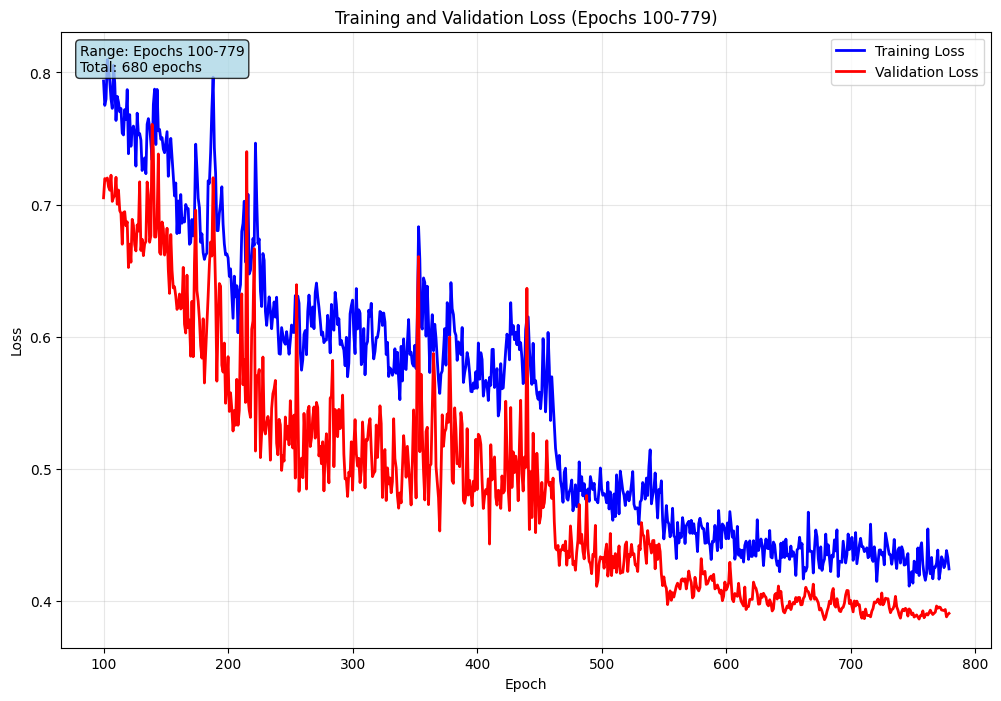

📊 Plot Range: Epochs 100 to 779
📈 Training Loss - Start: 0.7935, End: 0.4244
📉 Validation Loss - Start: 0.7052, End: 0.3908
🎯 Loss Reduction - Training: 0.3691
🎯 Loss Reduction - Validation: 0.3144

💡 To change range: Modify start_epoch and end_epoch variables
   Example: start_epoch = 100, end_epoch = 500 (for epochs 100-500)
   Example: start_epoch = 1, end_epoch = 100 (for first 100 epochs)
   Example: start_epoch = 900, end_epoch = 1000 (for last 100 epochs)


In [119]:
# Simple Training Curves Plot with Range Selection
import matplotlib.pyplot as plt

# You can modify these values to plot specific ranges
start_epoch = 100          # Starting epoch for plot (1 for full range)
end_epoch = 1000    # Ending epoch for plot (use len(training_data['epochs']) for full range)

# Validate range
start_epoch = max(1, min(start_epoch, len(training_data['epochs'])))
end_epoch = min(end_epoch, len(training_data['epochs']))

if start_epoch > end_epoch:
    start_epoch, end_epoch = 1, len(training_data['epochs'])

# Extract data for the specified range
plot_epochs = training_data['epochs'][start_epoch-1:end_epoch]
plot_train_losses = training_data['train_losses'][start_epoch-1:end_epoch]
plot_val_losses = training_data['val_losses'][start_epoch-1:end_epoch]

plt.figure(figsize=(12, 8))
plt.plot(plot_epochs, plot_train_losses, 'b-', label='Training Loss', linewidth=2)
plt.plot(plot_epochs, plot_val_losses, 'r-', label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training and Validation Loss (Epochs {start_epoch}-{end_epoch})')
plt.legend()
plt.grid(True, alpha=0.3)

# Add range info text box
range_text = f'Range: Epochs {start_epoch}-{end_epoch}\nTotal: {end_epoch-start_epoch+1} epochs'
plt.text(0.02, 0.98, range_text, transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.show()

print(f"📊 Plot Range: Epochs {start_epoch} to {end_epoch}")
print(f"📈 Training Loss - Start: {plot_train_losses[0]:.4f}, End: {plot_train_losses[-1]:.4f}")
print(f"📉 Validation Loss - Start: {plot_val_losses[0]:.4f}, End: {plot_val_losses[-1]:.4f}")
print(f"🎯 Loss Reduction - Training: {plot_train_losses[0] - plot_train_losses[-1]:.4f}")
print(f"🎯 Loss Reduction - Validation: {plot_val_losses[0] - plot_val_losses[-1]:.4f}")

print(f"\n💡 To change range: Modify start_epoch and end_epoch variables")
print(f"   Example: start_epoch = 100, end_epoch = 500 (for epochs 100-500)")
print(f"   Example: start_epoch = 1, end_epoch = 100 (for first 100 epochs)")
print(f"   Example: start_epoch = 900, end_epoch = 1000 (for last 100 epochs)")

In [120]:
import numpy as np
import yaml
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import r2_score

In [121]:
model.eval()
sample_index = 1
test_sample = val_dataset[sample_index].to(device)
print(f"Selected test sample #{sample_index} for prediction.")

with torch.no_grad():
    test_sample.batch = torch.zeros(test_sample.x.size(0), dtype=torch.long, device=device)
    predicted_y_tensor = model(test_sample)

Selected test sample #1 for prediction.


In [122]:
N_BANDS = 24
N_QPOINTS = 357

true_y = test_sample.y.cpu().numpy().flatten()
predicted_y = predicted_y_tensor.cpu().numpy().flatten()

true_bands = true_y.reshape((N_QPOINTS, N_BANDS))
predicted_bands = predicted_y.reshape((N_QPOINTS, N_BANDS))

r2_value = r2_score(true_y, predicted_y)
print(f"\nCalculated R² Score for this sample: {r2_value:.4f}")

reference_yaml = 'band/band (1).yaml' 
with open(reference_yaml, 'r') as f:
    yaml_data = yaml.safe_load(f)
distances = [d['distance'] for d in yaml_data['phonon']]


Calculated R² Score for this sample: 0.9736


Plotting bands (1-based indices): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


C:\Users\Victor\AppData\Local\Temp\ipykernel_19428\2792548175.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('turbo', N_BANDS)


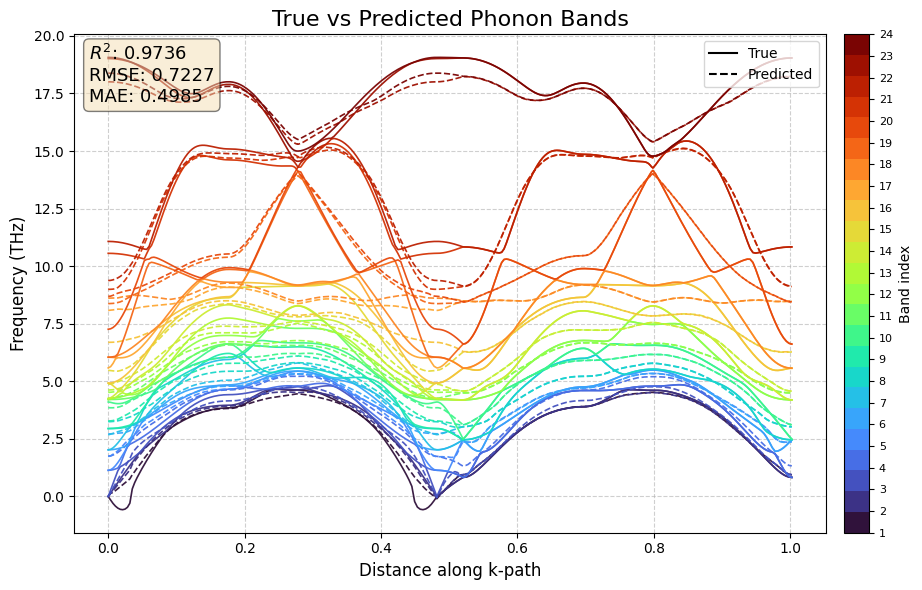


Per-band metrics (rounded to 4 decimals):
 Band      R2   RMSE    MAE
    1  0.9794 0.2402 0.1396
    2  0.9956 0.1042 0.0880
    3  0.9745 0.2487 0.2059
    4  0.9536 0.3156 0.2514
    5  0.9702 0.2467 0.1811
    6  0.9426 0.2990 0.2141
    7  0.8782 0.4898 0.4054
    8  0.8927 0.4119 0.3597
    9  0.9304 0.3887 0.3533
   10  0.9215 0.3619 0.3080
   11  0.8773 0.4393 0.3279
   12  0.8647 0.4823 0.3947
   13  0.9086 0.4628 0.4222
   14  0.8954 0.5067 0.4561
   15  0.7690 0.7995 0.6900
   16  0.6263 1.0059 0.8726
   17  0.1078 1.4771 1.1731
   18 -0.0275 1.5411 1.2003
   19  0.7240 1.1814 0.9509
   20  0.7696 0.9590 0.8259
   21  0.8162 0.8132 0.5635
   22  0.7939 0.8442 0.5830
   23  0.7819 0.6241 0.5347
   24  0.8329 0.5293 0.4625

Averages across 24 bands (sum/count): R2=0.7991, RMSE=0.6155, MAE=0.4985


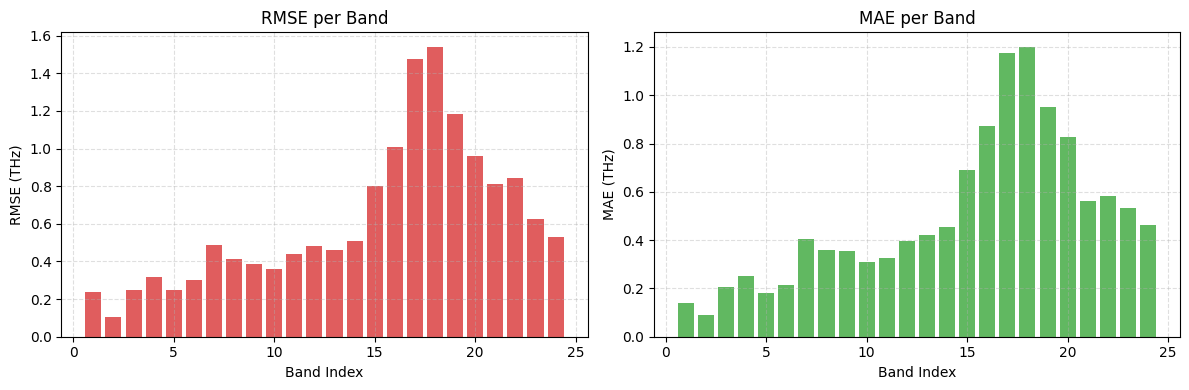

Overall -> R^2: 0.973609 | RMSE: 0.722697 | MAE: 0.498498


In [123]:
# Overlay true and predicted phonon bands in a single plot, with per-band colors and extra metrics (R^2, RMSE, MAE)
from matplotlib.lines import Line2D
import matplotlib as mpl
import pandas as pd

# ===== Band selection controls =====
# Options:
#   - band_selection = 'all'
#   - band_selection = '1-3,6,12-14'  # 1-based inclusive ranges and/or comma-separated indices
# band_selection = [17]    # list of 1-based indices
band_selection = 'all'  # change this to select which bands to plot

def parse_band_selection(sel, n):
    """Return a list of 0-based band indices to plot.
    Accepts 'all', a comma/range string like '1-3,6,10-12', or a list of ints (1-based)."""
    if sel is None:
        return list(range(n))
    if isinstance(sel, str):
        s = sel.strip().lower()
        if s == 'all' or s == '':
            return list(range(n))
        vals = []
        for part in s.replace(' ', '').split(','):
            if not part:
                continue
            if '-' in part:
                a, b = part.split('-')
                a, b = int(a), int(b)
                step = 1 if a <= b else -1
                vals.extend(list(range(a, b + step, step)))
            else:
                vals.append(int(part))
    else:
        # Assume iterable of ints
        vals = [int(v) for v in sel]

    # Convert to 0-based, validate, and de-duplicate while preserving order
    out, seen = [], set()
    for v in vals:
        idx = v - 1 if v >= 1 else v  # treat provided indices as 1-based
        if 0 <= idx < n and idx not in seen:
            out.append(idx)
            seen.add(idx)
    return out if out else list(range(n))

selected_idx = parse_band_selection(band_selection, N_BANDS)
selected_idx_1based = [i + 1 for i in selected_idx]
print(f"Plotting bands (1-based indices): {selected_idx_1based}")

# Compute overall error metrics using flattened arrays
errors = predicted_y - true_y
rmse_value = float(np.sqrt(np.mean(errors ** 2)))
mae_value = float(np.mean(np.abs(errors)))

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Determine shared y-limits using both true and predicted bands
ymin = min(np.min(true_bands), np.min(predicted_bands)) - 1
ymax = max(np.max(true_bands), np.max(predicted_bands)) + 1

# Discrete colormap with N_BANDS distinct colors (consistent for true/predicted of the same band)
cmap = mpl.cm.get_cmap('turbo', N_BANDS)
colors_list = [cmap(i) for i in range(N_BANDS)]

# Plot only selected bands (same color per band index)
for i in selected_idx:
    c = colors_list[i]
    ax.plot(distances, true_bands[:, i], lw=1.2, color=c, alpha=0.95)
    ax.plot(distances, predicted_bands[:, i], lw=1.2, color=c, alpha=0.95, linestyle='--')

ax.set_title('True vs Predicted Phonon Bands', fontsize=16)
ax.set_xlabel('Distance along k-path', fontsize=12)
ax.set_ylabel('Frequency (THz)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(ymin, ymax)

# Legend for line style (True vs Predicted)
legend_elements = [
    Line2D([0], [0], color='black', lw=1.5, linestyle='-', label='True'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='Predicted')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)

# Colorbar to map colors to band index (1..N_BANDS)
norm = mpl.colors.Normalize(vmin=1, vmax=N_BANDS)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Band index')
# Use selected indices for ticks if a subset, otherwise all
if len(selected_idx) < N_BANDS:
    cbar.set_ticks(selected_idx_1based)
else:
    cbar.set_ticks(np.arange(1, N_BANDS + 1))
cbar.ax.tick_params(labelsize=8)

# Overall metrics annotation box
metrics_text = f"$R^2$: {r2_value:.4f}\nRMSE: {rmse_value:.4f}\nMAE: {mae_value:.4f}"
ax.text(0.02, 0.98, metrics_text,
        transform=ax.transAxes,
        fontsize=13,
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Per-band metrics -----------------------------------------------------------
# Vectorized per-band RMSE/MAE
band_rmse = np.sqrt(np.mean((predicted_bands - true_bands) ** 2, axis=0))
band_mae = np.mean(np.abs(predicted_bands - true_bands), axis=0)

# Safe R^2 per band (handle near-constant ground-truth bands)
def _safe_r2(y_true, y_pred):
    if np.var(y_true) < 1e-12:
        return np.nan
    return float(r2_score(y_true, y_pred))

band_r2 = np.array([
    _safe_r2(true_bands[:, i], predicted_bands[:, i]) for i in range(N_BANDS)
])

# Assemble and print a neat table
metrics_df = pd.DataFrame({
    'Band': np.arange(1, N_BANDS + 1),
    'R2': band_r2,
    'RMSE': band_rmse,
    'MAE': band_mae,
})
print('\nPer-band metrics (rounded to 4 decimals):')
print(metrics_df.round({'R2': 4, 'RMSE': 4, 'MAE': 4}).to_string(index=False))

# Averages across all 24 bands (sum divided by count)
valid_r2_mask = ~np.isnan(band_r2)
avg_r2_bands = float(np.sum(band_r2[valid_r2_mask]) / np.sum(valid_r2_mask)) if np.any(valid_r2_mask) else float('nan')
avg_rmse_bands = float(np.sum(band_rmse) / len(band_rmse))
avg_mae_bands = float(np.sum(band_mae) / len(band_mae))
print(f"\nAverages across {np.sum(valid_r2_mask)} bands (sum/count): R2={avg_r2_bands:.4f}, RMSE={avg_rmse_bands:.4f}, MAE={avg_mae_bands:.4f}")

# Optional: compact bar charts for RMSE and MAE per band
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
bands_idx = np.arange(1, N_BANDS + 1)
axes2[0].bar(bands_idx, band_rmse, color='tab:red', alpha=0.75)
axes2[0].set_title('RMSE per Band')
axes2[0].set_xlabel('Band Index')
axes2[0].set_ylabel('RMSE (THz)')
axes2[0].grid(True, linestyle='--', alpha=0.4)

axes2[1].bar(bands_idx, band_mae, color='tab:green', alpha=0.75)
axes2[1].set_title('MAE per Band')
axes2[1].set_xlabel('Band Index')
axes2[1].set_ylabel('MAE (THz)')
axes2[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Also print overall metrics for logging
print(f"Overall -> R^2: {r2_value:.6f} | RMSE: {rmse_value:.6f} | MAE: {mae_value:.6f}")

🧪 Material Analysis for Sample 1:
   Atomic numbers: [7, 13, 42]
   Elements: ['N', 'Al', 'Mo']
   Composition: N2Al2Mo4
   Total atoms: 8


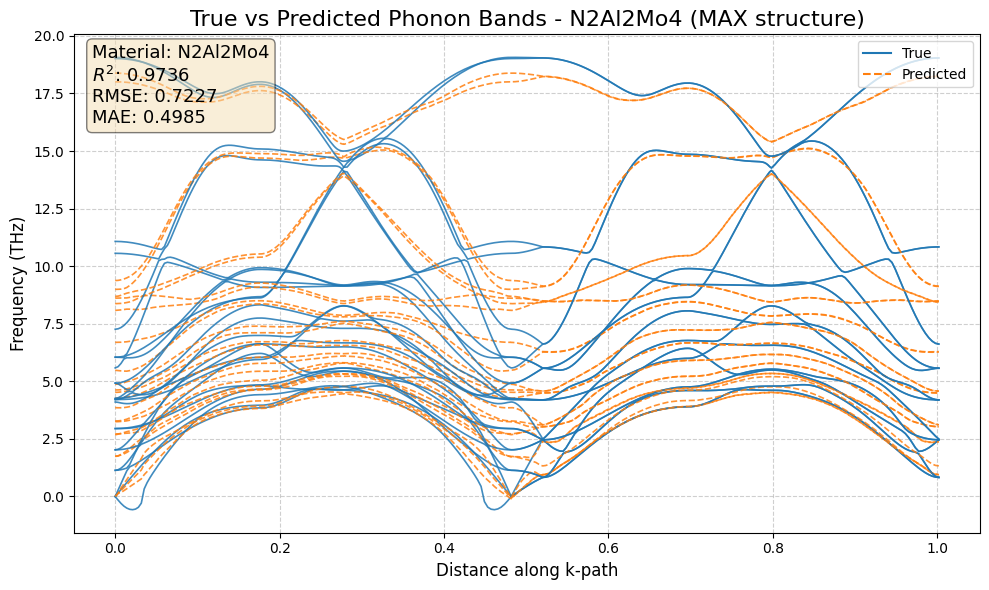

Material: N2Al2Mo4 | R^2: 0.973609 | RMSE: 0.722697 | MAE: 0.498498
MAX Phase Structure: N2Al2Mo4 with 8 atoms


In [124]:
# Overlay true and predicted phonon bands in a single plot, with extra metrics (R^2, RMSE, MAE)
from matplotlib.lines import Line2D

def atomic_number_to_symbol(z):
    """Convert atomic number to element symbol"""
    z_to_symbol = {
        1: 'H', 2: 'He', 3: 'Li', 4: 'Be', 5: 'B', 6: 'C', 7: 'N', 8: 'O', 9: 'F', 10: 'Ne',
        11: 'Na', 12: 'Mg', 13: 'Al', 14: 'Si', 15: 'P', 16: 'S', 17: 'Cl', 18: 'Ar',
        19: 'K', 20: 'Ca', 21: 'Sc', 22: 'Ti', 23: 'V', 24: 'Cr', 25: 'Mn', 26: 'Fe',
        27: 'Co', 28: 'Ni', 29: 'Cu', 30: 'Zn', 31: 'Ga', 32: 'Ge', 33: 'As', 34: 'Se',
        35: 'Br', 36: 'Kr', 37: 'Rb', 38: 'Sr', 39: 'Y', 40: 'Zr', 41: 'Nb', 42: 'Mo',
        43: 'Tc', 44: 'Ru', 45: 'Rh', 46: 'Pd', 47: 'Ag', 48: 'Cd', 49: 'In', 50: 'Sn',
        51: 'Sb', 52: 'Te', 53: 'I', 54: 'Xe', 55: 'Cs', 56: 'Ba', 57: 'La', 58: 'Ce',
        59: 'Pr', 60: 'Nd', 61: 'Pm', 62: 'Sm', 63: 'Eu', 64: 'Gd', 65: 'Tb', 66: 'Dy',
        67: 'Ho', 68: 'Er', 69: 'Tm', 70: 'Yb', 71: 'Lu', 72: 'Hf', 73: 'Ta', 74: 'W',
        75: 'Re', 76: 'Os', 77: 'Ir', 78: 'Pt', 79: 'Au', 80: 'Hg', 81: 'Tl', 82: 'Pb',
        83: 'Bi', 84: 'Po', 85: 'At', 86: 'Rn', 87: 'Fr', 88: 'Ra', 89: 'Ac', 90: 'Th',
        91: 'Pa', 92: 'U', 93: 'Np', 94: 'Pu', 95: 'Am', 96: 'Cm', 97: 'Bk', 98: 'Cf',
    }
    return z_to_symbol.get(int(z), f'X{int(z)}')

# Extract material information from test sample
atomic_numbers = test_sample.z.cpu().numpy()
unique_elements, counts = np.unique(atomic_numbers, return_counts=True)
element_symbols = [atomic_number_to_symbol(z) for z in unique_elements]
composition_str = ''.join([f'{symbol}{count}' if count > 1 else symbol for symbol, count in zip(element_symbols, counts)])

print(f"🧪 Material Analysis for Sample {sample_index}:")
print(f"   Atomic numbers: {[int(z) for z in unique_elements]}")
print(f"   Elements: {element_symbols}")
print(f"   Composition: {composition_str}")
print(f"   Total atoms: {len(atomic_numbers)}")

# Compute per-sample error metrics using flattened arrays
errors = predicted_y - true_y
rmse_value = float(np.sqrt(np.mean(errors ** 2)))
mae_value = float(np.mean(np.abs(errors)))

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Determine shared y-limits using both true and predicted bands
ymin = min(np.min(true_bands), np.min(predicted_bands)) - 1
ymax = max(np.max(true_bands), np.max(predicted_bands)) + 1

# Plot both sets of bands on the same axes with different styles/colors
for i in range(N_BANDS):
    ax.plot(distances, true_bands[:, i], lw=1.2, color='tab:blue', alpha=0.85)
    ax.plot(distances, predicted_bands[:, i], lw=1.2, color='tab:orange', alpha=0.85, linestyle='--')

# Update title to include material information
ax.set_title(f'True vs Predicted Phonon Bands - {composition_str} (MAX structure)', fontsize=16)
ax.set_xlabel('Distance along k-path', fontsize=12)
ax.set_ylabel('Frequency (THz)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(ymin, ymax)

# Add a compact legend using proxy artists for clarity
legend_elements = [
    Line2D([0], [0], color='tab:blue', lw=1.5, label='True'),
    Line2D([0], [0], color='tab:orange', lw=1.5, linestyle='--', label='Predicted')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)

# Metrics annotation box with material info
metrics_text = f"Material: {composition_str}\n$R^2$: {r2_value:.4f}\nRMSE: {rmse_value:.4f}\nMAE: {mae_value:.4f}"
ax.text(0.02, 0.98, metrics_text,
        transform=ax.transAxes,
        fontsize=13,
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Also print metrics in the cell output for logging
print(f"Material: {composition_str} | R^2: {r2_value:.6f} | RMSE: {rmse_value:.6f} | MAE: {mae_value:.6f}")
print(f"MAX Phase Structure: {composition_str} with {len(atomic_numbers)} atoms")

In [125]:
model.eval()
all_r2_scores = []  # R² per sample using flattened arrays (kept for reference)

# New: per-sample averages of per-band metrics
sample_avg_r2 = []   # average of per-band R² per sample
sample_avg_rmse = [] # average of per-band RMSE per sample
sample_avg_mae = []  # average of per-band MAE per sample

print("\n--- Evaluating per-sample metrics (averaged over 24 bands) for all test samples ---")

# Safe R² helper for per-band computation
def _safe_r2(y_true, y_pred):
    if np.var(y_true) < 1e-12:
        return np.nan
    return float(r2_score(y_true, y_pred))

with torch.no_grad():
    for i, test_sample in enumerate(val_dataset):
        sample_on_device = test_sample.to(device)
        
        # Single-graph batch assignment
        sample_on_device.batch = torch.zeros(sample_on_device.x.size(0), dtype=torch.long, device=device)
        predicted_y_tensor = model(sample_on_device)
        
        true_y = sample_on_device.y.cpu().numpy().flatten()
        predicted_y = predicted_y_tensor.cpu().numpy().flatten()

        # Original overall R² for the flattened vectors
        r2 = r2_score(true_y, predicted_y)
        all_r2_scores.append(r2)

        # Reshape to (N_QPOINTS, N_BANDS) and compute per-band metrics like cell 38
        true_bands = true_y.reshape((N_QPOINTS, N_BANDS))
        pred_bands = predicted_y.reshape((N_QPOINTS, N_BANDS))

        band_rmse = np.sqrt(np.mean((pred_bands - true_bands) ** 2, axis=0))
        band_mae = np.mean(np.abs(pred_bands - true_bands), axis=0)
        band_r2 = np.array([_safe_r2(true_bands[:, j], pred_bands[:, j]) for j in range(N_BANDS)])

        # Averages across 24 bands (sum/count); ignore NaNs in R²
        valid_r2_mask = ~np.isnan(band_r2)
        avg_r2_bands = float(np.sum(band_r2[valid_r2_mask]) / np.sum(valid_r2_mask)) if np.any(valid_r2_mask) else float('nan')
        avg_rmse_bands = float(np.sum(band_rmse) / len(band_rmse))
        avg_mae_bands = float(np.sum(band_mae) / len(band_mae))

        sample_avg_r2.append(avg_r2_bands)
        sample_avg_rmse.append(avg_rmse_bands)
        sample_avg_mae.append(avg_mae_bands)

        print(f"  - Sample {i}: flat R²={r2:.4f} | band-avg R²={avg_r2_bands:.4f} | band-avg RMSE={avg_rmse_bands:.4f} | band-avg MAE={avg_mae_bands:.4f}")

# Summaries across all validation samples
average_r2 = np.mean(all_r2_scores)
avg_of_sample_avg_r2 = float(np.nanmean(sample_avg_r2)) if len(sample_avg_r2) > 0 else float('nan')
avg_of_sample_avg_rmse = float(np.mean(sample_avg_rmse)) if len(sample_avg_rmse) > 0 else float('nan')
avg_of_sample_avg_mae = float(np.mean(sample_avg_mae)) if len(sample_avg_mae) > 0 else float('nan')

print("-" * 60)
print(f"Average flat R² over {len(val_dataset)} test samples: {average_r2:.4f}")
print(f"Average of band-averaged metrics over {len(val_dataset)} samples:")
print(f"  • R² (band-avg then sample-avg): {avg_of_sample_avg_r2:.4f}")
print(f"  • RMSE (band-avg then sample-avg): {avg_of_sample_avg_rmse:.4f}")
print(f"  • MAE  (band-avg then sample-avg): {avg_of_sample_avg_mae:.4f}")
print("-" * 60)


--- Evaluating per-sample metrics (averaged over 24 bands) for all test samples ---
  - Sample 0: flat R²=0.9897 | band-avg R²=-4.7408 | band-avg RMSE=0.3307 | band-avg MAE=0.2881
  - Sample 1: flat R²=0.9736 | band-avg R²=0.7991 | band-avg RMSE=0.6155 | band-avg MAE=0.4985
  - Sample 2: flat R²=0.9975 | band-avg R²=-2.4734 | band-avg RMSE=0.2473 | band-avg MAE=0.2192
  - Sample 3: flat R²=0.9790 | band-avg R²=0.0068 | band-avg RMSE=0.6844 | band-avg MAE=0.5810
  - Sample 4: flat R²=0.9936 | band-avg R²=0.2006 | band-avg RMSE=0.2936 | band-avg MAE=0.2633
  - Sample 5: flat R²=0.9470 | band-avg R²=-1.2933 | band-avg RMSE=0.6477 | band-avg MAE=0.5319
  - Sample 6: flat R²=0.9968 | band-avg R²=-0.7073 | band-avg RMSE=0.2781 | band-avg MAE=0.2434
  - Sample 3: flat R²=0.9790 | band-avg R²=0.0068 | band-avg RMSE=0.6844 | band-avg MAE=0.5810
  - Sample 4: flat R²=0.9936 | band-avg R²=0.2006 | band-avg RMSE=0.2936 | band-avg MAE=0.2633
  - Sample 5: flat R²=0.9470 | band-avg R²=-1.2933 | ban

In [126]:
# 🔄 Training Dataset Evaluation - Same Metrics as Validation
model.eval()
train_all_r2_scores = []  # R² per sample using flattened arrays (kept for reference)

# New: per-sample averages of per-band metrics for TRAINING data
train_sample_avg_r2 = []   # average of per-band R² per sample
train_sample_avg_rmse = [] # average of per-band RMSE per sample
train_sample_avg_mae = []  # average of per-band MAE per sample

print("\n🎯 --- Evaluating per-sample metrics (averaged over 24 bands) for TRAINING samples ---")
print("This will help compare training vs validation performance")

# Use the same safe R² helper as validation evaluation
def _safe_r2_train(y_true, y_pred):
    if np.var(y_true) < 1e-12:
        return np.nan
    return float(r2_score(y_true, y_pred))

with torch.no_grad():
    # Evaluate first 100 samples from training set to avoid overwhelming output
    # You can change this number if you want to evaluate more or all samples
    max_train_samples = len(train_dataset)
    
    for i, train_sample in enumerate(train_dataset[:max_train_samples]):
        sample_on_device = train_sample.to(device)
        
        # Single-graph batch assignment
        sample_on_device.batch = torch.zeros(sample_on_device.x.size(0), dtype=torch.long, device=device)
        predicted_y_tensor = model(sample_on_device)
        
        true_y = sample_on_device.y.cpu().numpy().flatten()
        predicted_y = predicted_y_tensor.cpu().numpy().flatten()

        # Original overall R² for the flattened vectors
        r2 = r2_score(true_y, predicted_y)
        train_all_r2_scores.append(r2)

        # Reshape to (N_QPOINTS, N_BANDS) and compute per-band metrics
        true_bands = true_y.reshape((N_QPOINTS, N_BANDS))
        pred_bands = predicted_y.reshape((N_QPOINTS, N_BANDS))

        band_rmse = np.sqrt(np.mean((pred_bands - true_bands) ** 2, axis=0))
        band_mae = np.mean(np.abs(pred_bands - true_bands), axis=0)
        band_r2 = np.array([_safe_r2_train(true_bands[:, j], pred_bands[:, j]) for j in range(N_BANDS)])

        # Averages across 24 bands (sum/count); ignore NaNs in R²
        valid_r2_mask = ~np.isnan(band_r2)
        avg_r2_bands = float(np.sum(band_r2[valid_r2_mask]) / np.sum(valid_r2_mask)) if np.any(valid_r2_mask) else float('nan')
        avg_rmse_bands = float(np.sum(band_rmse) / len(band_rmse))
        avg_mae_bands = float(np.sum(band_mae) / len(band_mae))

        train_sample_avg_r2.append(avg_r2_bands)
        train_sample_avg_rmse.append(avg_rmse_bands)
        train_sample_avg_mae.append(avg_mae_bands)

        # Print every 10th sample to avoid too much output
        if i % 10 == 0 or i < 5:
            print(f"  - Train Sample {i}: flat R²={r2:.4f} | band-avg R²={avg_r2_bands:.4f} | band-avg RMSE={avg_rmse_bands:.4f} | band-avg MAE={avg_mae_bands:.4f}")

# Summaries across evaluated training samples
train_average_r2 = np.mean(train_all_r2_scores)
train_avg_of_sample_avg_r2 = float(np.nanmean(train_sample_avg_r2)) if len(train_sample_avg_r2) > 0 else float('nan')
train_avg_of_sample_avg_rmse = float(np.mean(train_sample_avg_rmse)) if len(train_sample_avg_rmse) > 0 else float('nan')
train_avg_of_sample_avg_mae = float(np.mean(train_sample_avg_mae)) if len(train_sample_avg_mae) > 0 else float('nan')

print("-" * 60)
print(f"🎯 TRAINING SET RESULTS ({max_train_samples} samples evaluated):")
print(f"Average flat R² over {max_train_samples} training samples: {train_average_r2:.4f}")
print(f"Average of band-averaged metrics over {max_train_samples} samples:")
print(f"  • R² (band-avg then sample-avg): {train_avg_of_sample_avg_r2:.4f}")
print(f"  • RMSE (band-avg then sample-avg): {train_avg_of_sample_avg_rmse:.4f}")
print(f"  • MAE  (band-avg then sample-avg): {train_avg_of_sample_avg_mae:.4f}")
print("-" * 60)

# Compare with validation results (if available from previous cell)
if 'avg_of_sample_avg_r2' in globals():
    print(f"\n📊 TRAINING vs VALIDATION COMPARISON:")
    print(f"{'Metric':<25} {'Training':<12} {'Validation':<12} {'Difference':<12}")
    print("-" * 60)
    diff_r2 = train_avg_of_sample_avg_r2 - avg_of_sample_avg_r2
    diff_rmse = train_avg_of_sample_avg_rmse - avg_of_sample_avg_rmse  
    diff_mae = train_avg_of_sample_avg_mae - avg_of_sample_avg_mae
    
    print(f"{'Band-avg R²':<25} {train_avg_of_sample_avg_r2:<12.4f} {avg_of_sample_avg_r2:<12.4f} {diff_r2:<+12.4f}")
    print(f"{'Band-avg RMSE':<25} {train_avg_of_sample_avg_rmse:<12.4f} {avg_of_sample_avg_rmse:<12.4f} {diff_rmse:<+12.4f}")
    print(f"{'Band-avg MAE':<25} {train_avg_of_sample_avg_mae:<12.4f} {avg_of_sample_avg_mae:<12.4f} {diff_mae:<+12.4f}")
    
    # Interpretation
    print(f"\n🔍 INTERPRETATION:")
    if abs(diff_r2) < 0.01 and abs(diff_rmse) < 0.1 and abs(diff_mae) < 0.1:
        print("✅ Good balance: Training and validation metrics are very similar")
        print("   → Model is neither overfitting nor underfitting significantly")
    elif diff_r2 > 0.05 or (diff_rmse < -0.2 and diff_mae < -0.2):
        print("⚠️  Possible overfitting: Training performs much better than validation")
        print("   → Model may have memorized training data")
    elif diff_r2 < -0.05 or (diff_rmse > 0.2 and diff_mae > 0.2):
        print("⚠️  Possible underfitting: Validation performs better than training")
        print("   → Model may not have learned training data well enough")
    else:
        print("✅ Reasonable performance gap between training and validation")
    
    print("-" * 60)
else:
    print("⚠️  Validation results not available for comparison")
    print("   Run the validation evaluation cell first for comparison")

print(f"\n💡 Note: Evaluated {max_train_samples} out of {len(train_dataset)} training samples")
print(f"   To evaluate all training samples, change max_train_samples variable")


🎯 --- Evaluating per-sample metrics (averaged over 24 bands) for TRAINING samples ---
This will help compare training vs validation performance
  - Train Sample 0: flat R²=0.9983 | band-avg R²=0.9076 | band-avg RMSE=0.1899 | band-avg MAE=0.1605
  - Train Sample 1: flat R²=0.9981 | band-avg R²=-4.3709 | band-avg RMSE=0.1856 | band-avg MAE=0.1619
  - Train Sample 2: flat R²=0.9974 | band-avg R²=0.5608 | band-avg RMSE=0.2747 | band-avg MAE=0.2240
  - Train Sample 3: flat R²=0.9974 | band-avg R²=0.1805 | band-avg RMSE=0.2040 | band-avg MAE=0.1785
  - Train Sample 4: flat R²=0.9979 | band-avg R²=0.9025 | band-avg RMSE=0.2015 | band-avg MAE=0.1685
  - Train Sample 3: flat R²=0.9974 | band-avg R²=0.1805 | band-avg RMSE=0.2040 | band-avg MAE=0.1785
  - Train Sample 4: flat R²=0.9979 | band-avg R²=0.9025 | band-avg RMSE=0.2015 | band-avg MAE=0.1685
  - Train Sample 10: flat R²=0.9968 | band-avg R²=0.9418 | band-avg RMSE=0.2237 | band-avg MAE=0.1884
  - Train Sample 10: flat R²=0.9968 | band-av